In [1]:
import pandas as pd
from Bio import SeqIO
import sys
import os
from ast import literal_eval
import numpy as np


import pybedtools
from pybedtools import BedTool


#For plotting
from matplotlib.colors import LinearSegmentedColormap
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

#For statistics
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from scipy import stats
from scipy.stats import gaussian_kde
from scipy.stats import pearsonr
from scipy.stats import spearmanr
import itertools

import re
from Bio import SeqIO
import ast # for safe eveal, for parsing some of the data
import math
os.chdir('/home/labs/davidgo/nadavmi/backup')

#import importlib
#importlib.reload(const)

import const #to reload use import(importlib) and then importlib.reload(const)
#from const import MPRA_data_paths
from const import pos_active_ctrl_color,neg_active_ctrl_color,highlight_color,custom_cmap
from const import set_equal_plot_limits
from const import plot_color_pallete
from const import custom_cmap_bolder
from const import FONT_SIZE_small
const.set_plot_style()
import matplotlib.ticker as mtick


# This function receives a dataframe, coordinates columns, source assembly and target assembly. It lifts over the coords and adds lifted coords to the df.
# assuming coords are 1-based.
os.chdir('/home/labs/davidgo/Collaboration/Lab_Tools/liftOver/no_GUI')
from liftOver import initializer as initializer
from liftOver import liftOver_df as liftOver

os.chdir('/home/labs/davidgo/Collaboration/backup/humanMPRA/scripts/produce_paper_figures')

output_path = '/home/labs/davidgo/Collaboration/humanMPRA/paper/raw_plots/'

/home/labs/davidgo/nadavmi/.conda/envs/Nadav_python/lib/python3.12/site-packages/seaborn/_statistics.py:32: UserWarning: A NumPy version >=1.23.5 and <2.3.0 is required for this version of SciPy (detected version 2.4.2)
  from scipy.stats import gaussian_kde


In [ ]:
comb_df = pd.read_csv("/home/labs/davidgo/Collaboration/humanMPRA/chondrocytes/quantitative_analysis_combined/comb_df_combined_fdr.csv")
comaprative_input = comb_df[comb_df['input_comparative_combined']=='yes']

/tmp/ipykernel_676415/4165191819.py:1: DtypeWarning: Columns (55) have mixed types. Specify dtype option on import or set low_memory=False.
  comb_df = pd.read_csv("/home/labs/davidgo/Collaboration/humanMPRA/chondrocytes/quantitative_analysis_combined/comb_df_combined_fdr.csv")


In [5]:
print("Column names:")
print(comb_df.columns.tolist())
print("\n" + "="*80)

seq_325030_rows = comb_df[comb_df['oligo'].str.contains('seq_325030', na=False)]
print(f"\nseq_325030 oligos (in full dataset):")
print(seq_325030_rows[['oligo', 'count_rep_comb']].to_string())
print(f"\nCount values for seq_325030: {seq_325030_rows['count_rep_comb'].values}")

# Check for library information
if 'library' in comb_df.columns:
    print(f"\nLibraries for seq_325030: {seq_325030_rows['library'].values}")
elif 'batch' in comb_df.columns:
    print(f"\nBatches for seq_325030: {seq_325030_rows['batch'].values}")
else:
    print("\nAvailable ID columns:", [col for col in comb_df.columns if 'batch' in col.lower() or 'lib' in col.lower() or 'seq' in col.lower()])


Column names:
['oligo', 'RNA_chondrocytes_rep1', 'RNA_chondrocytes_rep2', 'RNA_chondrocytes_rep3', 'DNA_chondrocytes_rep1', 'DNA_chondrocytes_rep2', 'DNA_chondrocytes_rep3', 'statistic', 'control', 'zscore', 'mad.score', 'pval.empirical', 'pval.mad', 'pval.zscore', 'alpha', 'fdr.mad', 'possible_bcs', 'bcs_RNA_rep1', 'bcs_RNA_rep2', 'bcs_RNA_rep3', 'bcs_DNA_rep1', 'bcs_DNA_rep2', 'bcs_DNA_rep3', 'ratio_log_rep1', 'DNA_rep1', 'RNA_rep1', 'count_rep1', 'ratio_log_rep2', 'DNA_rep2', 'RNA_rep2', 'count_rep2', 'ratio_log_rep3', 'DNA_rep3', 'RNA_rep3', 'count_rep3', 'ratio_log_rep_comb', 'DNA_rep_comb', 'RNA_rep_comb', 'count_rep_comb', 'control_type', 'activity', 'max_UMI_RNA', 'max_UMI_DNA', 'max_UMI_RNA_rep1', 'max_UMI_DNA_rep1', 'max_UMI_RNA_rep2', 'max_UMI_DNA_rep2', 'max_UMI_RNA_rep3', 'max_UMI_DNA_rep3', 'fdr.mad_adjusted', 'activity_adjusted', 'input_comparative', 'coords', 'orientation_fix', 'fdr.mad_adjusted_combined', 'activity_adjusted_combined', 'input_comparative_combined']


se

In [6]:
# Extract library information from oligo names
def extract_library(oligo_name):
    """Extract library from oligo name (e.g., 'a2_L3' from end of string)"""
    if pd.isna(oligo_name):
        return None
    # Try to match library pattern at the end: aX_LY (e.g., a2_L3)
    import re
    match = re.search(r'(a\d+_L\d+)(?:$|_)', oligo_name)
    if match:
        return match.group(1)
    return None

# Test the function first
test_oligo = seq_325030_rows.iloc[0]['oligo']
test_lib = extract_library(test_oligo)
print(f"Test extraction on '{test_oligo}':")
print(f"  Extracted library: '{test_lib}'")

# Now apply to both dataframes
comb_df['library'] = comb_df['oligo'].apply(extract_library)
comaprative_input = comaprative_input.copy()  # Avoid the SettingWithCopyWarning
comaprative_input['library'] = comaprative_input['oligo'].apply(extract_library)

# Get seq_325030 from comparative input
seq_325030_rows = comaprative_input[comaprative_input['oligo'].str.contains('seq_325030', na=False)]

print(f"\n{'='*80}")
print("seq_325030 oligos in comparative input:")
print(f"{'='*80}")
print(seq_325030_rows[['oligo', 'count_rep_comb', 'library']].to_string())

seq_325030_counts = seq_325030_rows['count_rep_comb'].dropna().values
seq_325030_library = seq_325030_rows['library'].iloc[0]

print(f"\nseq_325030 counts: {seq_325030_counts}")
print(f"seq_325030 library: {seq_325030_library}")

# Calculate quantiles against all sequences in comparative input
all_counts_comp = comaprative_input['count_rep_comb'].dropna()
print(f"\n{'='*80}")
print(f"Quantiles vs ALL sequences in comparative dataset (n={len(all_counts_comp)}):")
print(f"{'='*80}")
for idx, row in seq_325030_rows.iterrows():
    count = row['count_rep_comb']
    oligo_short = row['oligo'].replace('seq_325030_chr14:90968484-90968753_SCREEN_', '')
    quantile = stats.percentileofscore(all_counts_comp, count)
    print(f"  {oligo_short}: {count:.0f} barcodes -> {quantile:.4f}th percentile")

# Get counts for the same library
if seq_325030_library:
    same_library_data = comaprative_input[comaprative_input['library'] == seq_325030_library]['count_rep_comb'].dropna()
    print(f"\n{'='*80}")
    print(f"Quantiles vs sequences in {seq_325030_library} library (n={len(same_library_data)}):")
    print(f"{'='*80}")
    for idx, row in seq_325030_rows.iterrows():
        count = row['count_rep_comb']
        oligo_short = row['oligo'].replace('seq_325030_chr14:90968484-90968753_SCREEN_', '')
        quantile = stats.percentileofscore(same_library_data, count)
        print(f"  {oligo_short}: {count:.0f} barcodes -> {quantile:.4f}th percentile")


Test extraction on 'seq_325030_chr14:90968484-90968753_SCREEN_ancestral_a2_L3':
  Extracted library: 'a2_L3'

seq_325030 oligos in comparative input:
                                                            oligo  count_rep_comb library
603472  seq_325030_chr14:90968484-90968753_SCREEN_ancestral_a2_L3          2838.0   a2_L3
603473    seq_325030_chr14:90968484-90968753_SCREEN_derived_a2_L3          2397.0   a2_L3

seq_325030 counts: [2838. 2397.]
seq_325030 library: a2_L3

Quantiles vs ALL sequences in comparative dataset (n=101653):
  ancestral_a2_L3: 2838 barcodes -> 99.9970th percentile
  derived_a2_L3: 2397 barcodes -> 99.9852th percentile

Quantiles vs sequences in a2_L3 library (n=14544):
  ancestral_a2_L3: 2838 barcodes -> 99.9931th percentile
  derived_a2_L3: 2397 barcodes -> 99.9656th percentile


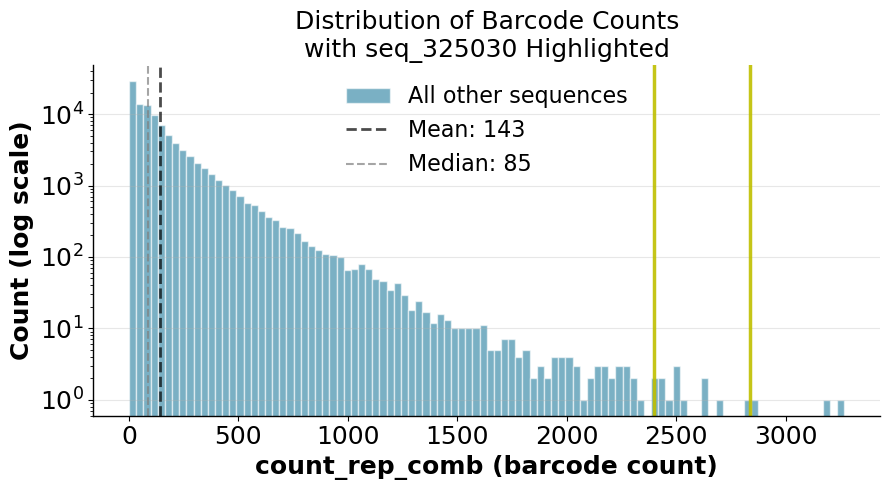


Plots saved to /home/labs/davidgo/Collaboration/humanMPRA/paper/raw_plots/


In [11]:
# Create a visualization with seq_325030 highlighted
fig, ax = plt.subplots(figsize=(9, 5))

all_data = comaprative_input['count_rep_comb'].dropna()

# Plot all data
ax.hist(all_data, bins=100, color=plot_color_pallete['barcode'], edgecolor='white', alpha=0.6, label='All other sequences')

# Highlight seq_325030
for count in seq_325030_counts:
    ax.axvline(count, color=highlight_color, linestyle='-', linewidth=2.5, alpha=0.9)

# Add mean and median lines
ax.axvline(all_data.mean(), color='black', linestyle='--', linewidth=2, label=f"Mean: {all_data.mean():.0f}", alpha=0.7)
ax.axvline(all_data.median(), color='gray', linestyle='--', linewidth=1.5, label=f"Median: {all_data.median():.0f}", alpha=0.7)

ax.set_yscale('log')
ax.set_xlabel('count_rep_comb (barcode count)', fontsize=FONT_SIZE_small)
ax.set_ylabel('Count (log scale)', fontsize=FONT_SIZE_small)
ax.set_title('Distribution of Barcode Counts\nwith seq_325030 Highlighted', fontsize=FONT_SIZE_small)
ax.legend(frameon=False, fontsize=FONT_SIZE_small-2)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(output_path + 'seq_325030_barcode_analysis.pdf', bbox_inches='tight', dpi=300)
plt.savefig(output_path + 'seq_325030_barcode_analysis.png', bbox_inches='tight', dpi=300)
plt.show()

print(f"\nPlots saved to {output_path}")

#### I think the before is dna_chunks_filter_sorted/dna001 and the after the filtering is dna_chunks_seq_325030_v2/dna_seq_325030_group1_v2.txt

In [32]:
file_path = r"/home/labs/davidgo/Collaboration/humanMPRA/chondrocytes/L3a2/output/mpranalyze_comparative/dna_chunks_filter_sorted/dna000"
#file_path = r"/home/labs/davidgo/Collaboration/humanMPRA/chondrocytes/L3a2/output/mpranalyze_comparative/rna_chunks_filter_sorted/rna000"
file_path = r"/home/labs/davidgo/Collaboration/humanMPRA/chondrocytes/L3a2/output/mpranalyze_comparative/dna_chunks_seq_325030_v2/dna_seq_325030_group1_v2.txt"

# Read the file and count non-zero numbers
with open(file_path, 'r') as f:
    content = f.read()

# Split by whitespace/newlines and convert to numbers, skipping non-numeric values
values = content.split()
numbers = []
for x in values:
    try:
        numbers.append(float(x))
    except ValueError:
        # Skip non-numeric values (like headers)
        pass

non_zero_count = sum(1 for num in numbers if num != 0)

print(f"Total numbers: {len(numbers)}")
print(f"Non-zero numbers: {non_zero_count}")

Total numbers: 20022
Non-zero numbers: 5486


# Comparing number of barcodes before and after filtering for extreme outliers
#### Since we do not have the combined barcode count for all reps before and after 

In [106]:
# Load ratio_wo_outliers tables for all requested libraries using only relevant columns
libraries = [
    "L1a1", "L1a2", "L1a3",
    "L2a1", "L2a2", "L2a3",
    "L3a1", "L3a2", "L3a3",
    "L4a1"
]

relevant_cols = [
    "oligo",
    "count_no_filter_rep1", "count_no_filter_rep2", "count_no_filter_rep3",
    "count_filtered_std2_rep1", "count_filtered_std2_rep2", "count_filtered_std2_rep3"
]

base_dir = "/home/labs/davidgo/Collaboration/humanMPRA/chondrocytes"


def table_path_for_library(lib_name):
    return os.path.join(base_dir, lib_name, "output", "filter", "ratio_wo_outliers_std2.csv")


library_dfs = []
failed_libraries = []

for lib in libraries:
    lib_path = table_path_for_library(lib)
    try:
        lib_df = pd.read_csv(lib_path, usecols=relevant_cols)
        lib_df["library"] = lib
        library_dfs.append(lib_df)
        print(f"Loaded {lib}: {lib_df.shape[0]:,} rows")
    except Exception as exc:
        failed_libraries.append((lib, lib_path, str(exc)))
        print(f"FAILED {lib}: {exc}")

if not library_dfs:
    raise RuntimeError("No library table was loaded. Check path template and file availability.")

# Concatenate all loaded libraries (same selected columns + library tag)
ratio_wo_outliers_all = pd.concat(library_dfs, ignore_index=True)

count_cols_before = ["count_no_filter_rep1", "count_no_filter_rep2", "count_no_filter_rep3"]
count_cols_after = ["count_filtered_std2_rep1", "count_filtered_std2_rep2", "count_filtered_std2_rep3"]

# Ensure numeric before aggregation
for c in count_cols_before + count_cols_after:
    ratio_wo_outliers_all[c] = pd.to_numeric(ratio_wo_outliers_all[c], errors="coerce").fillna(0)

# Global totals across all loaded libraries
totals_by_rep = pd.DataFrame({
    "replicate": ["rep1", "rep2", "rep3"],
    "before_filtering": [
        ratio_wo_outliers_all["count_no_filter_rep1"].sum(),
        ratio_wo_outliers_all["count_no_filter_rep2"].sum(),
        ratio_wo_outliers_all["count_no_filter_rep3"].sum()
    ],
    "after_filtering_std2": [
        ratio_wo_outliers_all["count_filtered_std2_rep1"].sum(),
        ratio_wo_outliers_all["count_filtered_std2_rep2"].sum(),
        ratio_wo_outliers_all["count_filtered_std2_rep3"].sum()
    ]
})

totals_by_rep["removed"] = totals_by_rep["before_filtering"] - totals_by_rep["after_filtering_std2"]
totals_by_rep["pct_removed"] = np.where(
    totals_by_rep["before_filtering"] > 0,
    (totals_by_rep["removed"] / totals_by_rep["before_filtering"]) * 100,
    np.nan
)

print("\n" + "=" * 80)
print(f"Loaded libraries: {len(library_dfs)} / {len(libraries)}")
print(f"Concatenated shape: {ratio_wo_outliers_all.shape}")
print("=" * 80)

print("\nBarcode totals by replicate (all loaded libraries combined):")
print(totals_by_rep.to_string(index=False, float_format=lambda x: f"{x:,.2f}"))

# Optional: per-library totals
per_library_totals = ratio_wo_outliers_all.groupby("library", as_index=False).agg({
    "count_no_filter_rep1": "sum", "count_no_filter_rep2": "sum", "count_no_filter_rep3": "sum",
    "count_filtered_std2_rep1": "sum", "count_filtered_std2_rep2": "sum", "count_filtered_std2_rep3": "sum"
})

print("\nPer-library totals:")
print(per_library_totals.to_string(index=False, max_rows=20))

if failed_libraries:
    print("\nFailed libraries:")
    for lib, path, err in failed_libraries:
        print(f"  {lib}: {path}")
        print(f"    {err}")

Loaded L1a1: 77,740 rows
Loaded L1a2: 78,022 rows
Loaded L1a3: 77,938 rows
Loaded L2a1: 77,129 rows
Loaded L2a2: 75,772 rows
Loaded L2a3: 74,052 rows
Loaded L3a1: 76,352 rows
Loaded L3a2: 75,363 rows
Loaded L3a3: 71,237 rows
Loaded L4a1: 55,753 rows

Loaded libraries: 10 / 10
Concatenated shape: (739358, 8)

Barcode totals by replicate (all loaded libraries combined):
replicate  before_filtering  after_filtering_std2      removed  pct_removed
     rep1     95,673,937.00         92,412,200.00 3,261,737.00         3.41
     rep2     96,817,421.00         93,563,837.00 3,253,584.00         3.36
     rep3     93,299,565.00         90,070,216.00 3,229,349.00         3.46

Per-library totals:
library  count_no_filter_rep1  count_no_filter_rep2  count_no_filter_rep3  count_filtered_std2_rep1  count_filtered_std2_rep2  count_filtered_std2_rep3
   L1a1             7068834.0             7134179.0             7107071.0                 6771693.0                 6836269.0                 6807977.0


In [20]:
# Average removed barcodes per replicate, treating each library-replicate independently
replicate_level_rows = []

for _, row in per_library_totals.iterrows():
    lib = row["library"]
    for rep in [1, 2, 3]:
        before = row[f"count_no_filter_rep{rep}"]
        after = row[f"count_filtered_std2_rep{rep}"]
        removed = before - after
        pct_removed = (removed / before * 100) if before > 0 else np.nan

        replicate_level_rows.append({
            "library": lib,
            "replicate": f"rep{rep}",
            "before": before,
            "after": after,
            "removed": removed,
            "pct_removed": pct_removed,
        })

replicate_level_stats = pd.DataFrame(replicate_level_rows)

avg_removed_per_replicate = replicate_level_stats["removed"].mean()
avg_pct_removed_per_replicate = replicate_level_stats["pct_removed"].mean()

# Optional reference metric: pooled percent removed across all replicate entries
pooled_pct_removed = (
    replicate_level_stats["removed"].sum() / replicate_level_stats["before"].sum() * 100
)

print("=" * 80)
print("Per-replicate removal summary (library-replicates treated as independent):")
print("=" * 80)
print(f"Number of replicate entries: {len(replicate_level_stats)}")
print(f"Average removed barcodes per replicate: {avg_removed_per_replicate:,.2f}")
print(f"Average percent removed per replicate: {avg_pct_removed_per_replicate:.4f}%")
print(f"Pooled percent removed (reference): {pooled_pct_removed:.4f}%")

print("\nPer-replicate table (first 15 rows):")
print(replicate_level_stats.head(15).to_string(index=False, float_format=lambda x: f"{x:,.4f}"))

Per-replicate removal summary (library-replicates treated as independent):
Number of replicate entries: 30
Average removed barcodes per replicate: 324,822.33
Average percent removed per replicate: 3.5762%
Pooled percent removed (reference): 3.4097%

Per-replicate table (first 15 rows):
library replicate          before           after      removed  pct_removed
   L1a1      rep1  7,068,834.0000  6,771,693.0000 297,141.0000       4.2035
   L1a1      rep2  7,134,179.0000  6,836,269.0000 297,910.0000       4.1758
   L1a1      rep3  7,107,071.0000  6,807,977.0000 299,094.0000       4.2084
   L1a2      rep1  8,147,002.0000  7,836,013.0000 310,989.0000       3.8172
   L1a2      rep2  8,159,501.0000  7,849,881.0000 309,620.0000       3.7946
   L1a2      rep3  8,205,634.0000  7,880,807.0000 324,827.0000       3.9586
   L1a3      rep1  6,604,946.0000  6,352,096.0000 252,850.0000       3.8282
   L1a3      rep2  6,480,769.0000  6,234,802.0000 245,967.0000       3.7953
   L1a3      rep3  6,544,499.

In [22]:
# Row-level loss per oligo per replicate (do NOT sum replicates)
row_level_loss_long_parts = []

for rep in [1, 2, 3]:
    before_col = f"count_no_filter_rep{rep}"
    after_col = f"count_filtered_std2_rep{rep}"

    part = ratio_wo_outliers_all[["library", "oligo", before_col, after_col]].copy()
    part = part.rename(columns={before_col: "before", after_col: "after"})
    part["replicate"] = f"rep{rep}"
    part["lost"] = part["before"] - part["after"]
    part["pct_lost"] = np.where(part["before"] > 0, (part["lost"] / part["before"]) * 100, np.nan)
    row_level_loss_long_parts.append(part)

row_level_loss_per_rep = pd.concat(row_level_loss_long_parts, ignore_index=True)

# Summary table: average row-level loss per replicate across all libraries combined
row_level_loss_summary = (
    row_level_loss_per_rep
    .groupby("replicate", as_index=False)
    .agg(
        n_rows=("oligo", "size"),
        avg_lost_per_row=("lost", "mean"),
        median_lost_per_row=("lost", "median"),
        avg_pct_lost_per_row=("pct_lost", "mean")
    )
)

overall_avg_lost_per_row_per_rep = row_level_loss_per_rep["lost"].mean()
overall_avg_pct_lost_per_row_per_rep = row_level_loss_per_rep["pct_lost"].mean()

print("=" * 80)
print("Row-level loss per oligo per replicate (all libraries combined)")
print("=" * 80)
print(f"Total row-replicate entries: {len(row_level_loss_per_rep):,}")
print(row_level_loss_summary.to_string(index=False, float_format=lambda x: f"{x:,.4f}"))

print("\nOverall (across rep1/rep2/rep3 row-level entries):")
print(f"Average barcodes lost per oligo per replicate: {overall_avg_lost_per_row_per_rep:,.4f}")
print(f"Average percent lost per oligo per replicate: {overall_avg_pct_lost_per_row_per_rep:,.4f}%")

Row-level loss per oligo per replicate (all libraries combined)
Total row-replicate entries: 2,218,074
replicate  n_rows  avg_lost_per_row  median_lost_per_row  avg_pct_lost_per_row
     rep1  739358            4.4116               3.0000                6.1726
     rep2  739358            4.4006               3.0000                6.1216
     rep3  739358            4.3678               3.0000                6.2270

Overall (across rep1/rep2/rep3 row-level entries):
Average barcodes lost per oligo per replicate: 4.3933
Average percent lost per oligo per replicate: 6.1737%


# Check the frequencies of hMPRA variants in 1K and HGDP

## Create a BED file of all SNPs in the library

In [57]:
# Load the library design and create the BED file
library_design = pd.read_excel("/home/labs/davidgo/Collaboration/humanMPRA/paper/extended_datasets/combined_library_design.xlsx")

In [108]:
from pathlib import Path
import re

# Parse genomic coordinates from the library_design "Variants (genomic)" column.
# Keep these coordinates 1-based for liftover input.
variants_col = "Variants (genomic)" if "Variants (genomic)" in library_design.columns else "variants_genomic"
coord_pattern = re.compile(r"(chr[\w]+):(\d+)(?:-(\d+))?")

records = []
unparsed_rows = []

for idx, row in library_design.iterrows():
    raw = row.get(variants_col)
    if pd.isna(raw):
        continue

    matches = coord_pattern.findall(str(raw))
    if not matches:
        unparsed_rows.append(idx)
        continue

    oligo_id = row.get("ID") if "ID" in library_design.columns else idx
    for chrom, start, end in matches:
        start_i = int(start)
        end_i = int(end) if end else start_i

        # Keep 1-based coordinates for liftover tool input.
        records.append((chrom, start_i, end_i, oligo_id, str(raw)))

variants_bed = pd.DataFrame(records, columns=["chrom", "start", "end", "id", "variant"])
variants_bed = variants_bed.sort_values(["chrom", "start", "end", "id"]).drop_duplicates()

# 3-column liftover input table (1-based coordinates; BED conversion happens after liftover).
positions_bed = variants_bed[["chrom", "start", "end"]].drop_duplicates().sort_values(["chrom", "start", "end"])

base_output = Path(output_path) if "output_path" in globals() else Path.cwd()
base_output.mkdir(parents=True, exist_ok=True)

input_coords_path = base_output / "library_design_variants_genomic_positions_for_liftover_1based.tsv"
positions_bed.to_csv(input_coords_path, sep="\t", header=False, index=False)

# Optional metadata table keeps oligo ID and original variant string (still 1-based).
metadata_bed_path = base_output / "library_design_variants_genomic_positions_for_liftover_1based.with_metadata.tsv"
variants_bed.to_csv(metadata_bed_path, sep="\t", header=False, index=False)

print(f"Wrote {len(positions_bed):,} unique 1-based coordinates to: {input_coords_path}")
print(f"Wrote {len(variants_bed):,} 1-based rows with metadata to: {metadata_bed_path}")
print(f"Rows with no parseable coordinates: {len(unparsed_rows):,}")

Wrote 561,410 unique 1-based coordinates to: /home/labs/davidgo/Collaboration/humanMPRA/paper/raw_plots/library_design_variants_genomic_positions_for_liftover_1based.tsv
Wrote 574,290 1-based rows with metadata to: /home/labs/davidgo/Collaboration/humanMPRA/paper/raw_plots/library_design_variants_genomic_positions_for_liftover_1based.with_metadata.tsv
Rows with no parseable coordinates: 0


In [95]:
lifted_coords = liftOver(positions_bed,chr_col = 'chrom',start_col= 'start', end_col= 'end',source_assembly= 'hg19',target_assembly='hg38')


Reading liftover chains
Mapping coordinates


Success LiftOver completed.


In [96]:
# Convert both coordinate sets to proper BED convention (0-based start, half-open end) after liftover.
# Original hg19 coordinates (currently 1-based)
positions_bed.rename(columns={'chrom': 'hg19_chr', 'start': 'hg19_start', 'end': 'hg19_end', 'lift_name': 'coord'}, inplace=True)
positions_bed['hg19_start'] = positions_bed['hg19_start'].astype(int) - 1
positions_bed['hg19_end'] = positions_bed['hg19_end'].astype(int)

# Lifted hg38 coordinates (currently 1-based from liftover output)
lifted_coords.rename(columns={0: 'hg38_chr', 1: 'hg38_start', 2: 'hg38_end', 3: 'coord'}, inplace=True)
lifted_coords['hg38_start'] = lifted_coords['hg38_start'].astype(int)
lifted_coords['hg38_end'] = lifted_coords['hg38_end'].astype(int)

In [97]:

# Merge on the coord column, keeping both coordinate sets
positions_bed_lift = positions_bed.merge(lifted_coords, left_on='coord', right_on='coord', how='right')

# Keep relevant columns: both coordinate sets, ID, and class
cols_to_keep = ['hg19_chr', 'hg19_start', 'hg19_end','hg38_chr', 'hg38_start', 'hg38_end']
positions_bed_lift = positions_bed_lift[cols_to_keep]

# Rename ID and class columns
positions_bed_lift.rename(columns={'3_x': 'ID'}, inplace=True)


In [101]:
positions_bed_lift.to_csv('/home/labs/davidgo/Collaboration/humanMPRA/oligo_fasta/bed_files/variant_positions_bed_lift_w_header.tsv', sep="\t", header=True, index=False)

## Read the variant frequency tables 
(ie, the files generated by extract_1kg_frequency.py)

In [62]:
positions_bed_lift = pd.read_csv('/home/labs/davidgo/Collaboration/humanMPRA/oligo_fasta/bed_files/variant_positions_bed_lift_w_header.tsv', sep="\t")

### gnomad v4 (which includes both HGDP and 1KG)

In [50]:
def prepare_frequency_table(
    path,
    sep="\t",
    filter_col="filter",
    numeric_cols=("AC", "AN", "AF_global"),
    collapse_alt_col="alt",
    collapse_ref_col="ref",
    collapse_variant_id_cols=("variant_id",),
    aggregate_an="median",
    af_col="AF_global",
):
    """Load, QC-filter, aggregate duplicate variants, print summary stats, and return table."""
    table = pd.read_csv(path, sep=sep, low_memory=False)
    orig_cols = table.columns.tolist()

    print(f"Number rows before QC filtering: {len(table):,}")
    table = table[table[filter_col].isna() | (table[filter_col] == "PASS")].copy()
    print(f"Number rows after QC filtering: {len(table):,}")

    # Collapse REF/ALT and present variant-id columns.
    variant_id_cols_present = [c for c in collapse_variant_id_cols if c in table.columns]
    collapse_cols = [c for c in [collapse_ref_col, collapse_alt_col] if c in table.columns] + variant_id_cols_present

    # Group by all non-aggregated columns, excluding collapsed columns.
    group_cols = [
        c for c in orig_cols
        if c not in (set(numeric_cols) | set(collapse_cols))
    ]

    for c in numeric_cols:
        if c in table.columns:
            table[c] = pd.to_numeric(table[c], errors="coerce").fillna(0)

    def _collapse_unique(s):
        return ",".join(pd.unique(s.dropna().astype(str)))

    agg_spec = {
        "AC": ("AC", "sum"),
        "AN": ("AN", aggregate_an),
        "AF_global": ("AF_global", "sum"),
    }
    for c in collapse_cols:
        agg_spec[c] = (c, _collapse_unique)

    # Check for other potentially collapsible columns (report only, do not apply).
    key_cols = table.columns[:3].tolist()
    dup_mask = table.duplicated(subset=key_cols, keep=False)
    additional_collapse_candidates = []
    if dup_mask.any():
        dup_df = table.loc[dup_mask].copy()
        protected = set(numeric_cols) | set(collapse_cols) | {filter_col} | set(key_cols)
        for c in dup_df.columns:
            if c in protected:
                continue
            nunique_by_key = dup_df.groupby(key_cols, dropna=False)[c].nunique(dropna=True)
            if (nunique_by_key > 1).any():
                additional_collapse_candidates.append(c)

    table = table.groupby(group_cols, dropna=False, as_index=False).agg(**agg_spec)

    af_numeric = pd.to_numeric(table[af_col], errors="coerce")
    avg_af_missing_as_zero = float(af_numeric.fillna(0.0).mean())

    print(f"Collapsed columns used: {collapse_cols}")
    if additional_collapse_candidates:
        print("Potential additional collapsible columns (check only):")
        print(additional_collapse_candidates)
    else:
        print("Potential additional collapsible columns (check only): none detected")

    print(f"Rows in table after collapsing based on variant position: {len(table):,}")
    print(f"Unique variants after QC filtering (first 3 cols): {table.iloc[:, :3].drop_duplicates().shape[0]:,}")
    print(f"Average allele frequency (missing as 0): {avg_af_missing_as_zero:.10f}")
    af_for_pct = pd.to_numeric(table[af_col], errors="coerce").fillna(0.0)

    # Use float64 to maintain precision during the mean calculation
    pct_gt_1 = (af_for_pct > 0.01).astype('float64').mean() * 100
    pct_gt_01 = (af_for_pct > 0.001).astype('float64').mean() * 100
    
    print(f"% of variants with freq >1%: {pct_gt_1:.10f}%")
    print(f"% of variants with freq >0.1%: {pct_gt_01:.10f}%")

    return table


In [51]:
# Apply once on gnomAD v4 table using the single helper function
path_gnomad_4 = "/home/labs/davidgo/Collaboration/humanMPRA/additional/variant_frequency_gnomad_v4/positions_bed_lift_gnomad_frequency.tsv"

table = prepare_frequency_table(path_gnomad_4)
freq_1kg_table = table  # Backward-compatible alias for downstream cells

Number rows before QC filtering: 573,432
Number rows after QC filtering: 565,379
Collapsed columns used: ['ref', 'alt', 'variant_id']
Potential additional collapsible columns (check only): none detected
Rows in table after collapsing based on variant position: 555,288
Unique variants after QC filtering (first 3 cols): 555,288
Average allele frequency (missing as 0): 0.0000066654
% of variants with freq >1%: 0.0054026019%
% of variants with freq >0.1%: 0.0397991673%


In [81]:
100-0.0397991673
100-0.0054026019

99.9945973981

In [79]:
zero_af_count = (freq_1kg_table["AF_global"] == 0).sum()
total_rows = len(freq_1kg_table)
zero_af_percent = (zero_af_count / total_rows) * 100 if total_rows > 0 else np.nan

print(f"Rows with AF_global == 0: {zero_af_count:,}")
print(f"Percent with AF_global == 0: {zero_af_percent:.4f}%")

Rows with AF_global == 0: 446,823
Percent with AF_global == 0: 80.4669%


In [77]:
sum(freq_1kg_table['AF_global']==0)

446823

### check for duplicated rows after collapsing

In [52]:
def find_duplicated_rows_by_first_cols(df, n_cols=3, sort_cols=("hg19_chr", "hg19_start"), verbose=True):
    subset_cols = df.columns[:n_cols]
    dup_mask = df.duplicated(subset=subset_cols, keep=False)

    duplicated_rows = df.loc[dup_mask].copy()
    if all(col in duplicated_rows.columns for col in sort_cols):
        duplicated_rows = duplicated_rows.sort_values(list(sort_cols))
    duplicated_rows = duplicated_rows.reset_index(drop=True)

    n_dups = len(duplicated_rows)

    if verbose:
        print(f"Columns used: {list(subset_cols)}")
        print(f"Duplicated rows (based on cols 1-{n_cols}): {n_dups:,}")

    return duplicated_rows, dup_mask, n_dups, subset_cols


duplicated_rows, dup_mask, n_dups, subset_cols = find_duplicated_rows_by_first_cols(freq_1kg_table)

Columns used: ['hg19_chr', 'hg19_start', 'hg19_end']
Duplicated rows (based on cols 1-3): 0


### Histogram of AFs

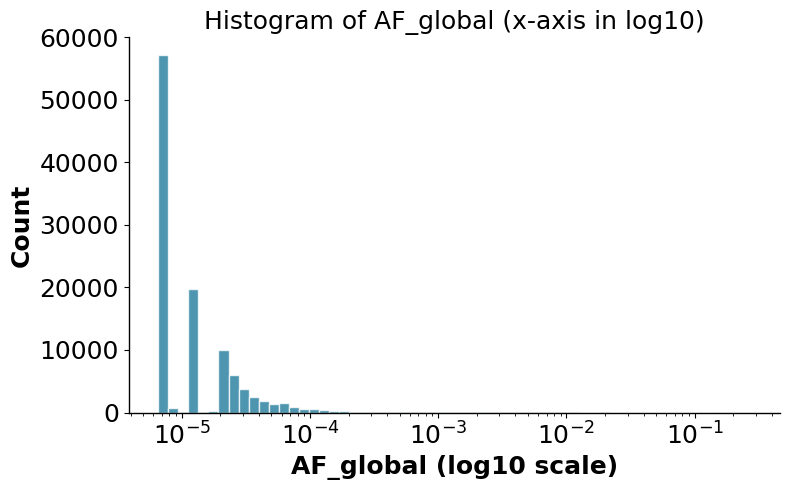

Plotted 108,465 variants with AF_global > 0
Excluded 446,823 rows with AF_global <= 0


In [55]:
def plot_af_global_histogram(df, af_col="AF_global", bins_count=60):
    """Plot AF histogram on a log10 x-axis and return plotting intermediates."""
    af = pd.to_numeric(df[af_col], errors="coerce")
    af_pos = af[(af > 0) & af.notna()]

    if af_pos.empty:
        raise ValueError(f"No positive values found in {af_col}.")

    fig, ax = plt.subplots(figsize=(8, 5))
    bins = np.logspace(np.log10(af_pos.min()), np.log10(af_pos.max()), bins_count)
    ax.hist(af_pos, bins=bins, color=plot_color_pallete["barcode"], edgecolor="white", alpha=0.8)

    ax.set_xscale("log", base=10)
    ax.set_xlabel("AF_global (log10 scale)", fontsize=FONT_SIZE_small)
    ax.set_ylabel("Count", fontsize=FONT_SIZE_small)
    ax.set_title("Histogram of AF_global (x-axis in log10)", fontsize=FONT_SIZE_small)

    plt.tight_layout()
    plt.show()

    return fig, ax, af, af_pos


fig, ax, af, af_pos = plot_af_global_histogram(freq_1kg_table)
print(f"Plotted {len(af_pos):,} variants with AF_global > 0")
print(f"Excluded {(af <= 0).sum():,} rows with AF_global <= 0")

In [63]:
def build_validation_rows(library_design_df, positions_bed_lift_df, freq_table):
    """Build validation rows by mapping hMPRA variants to lifted coords and 1KG frequency rows."""
    variants_col = "Variants (genomic)" if "Variants (genomic)" in library_design_df.columns else "variants_genomic"

    # 1) Explode rows so each variant token is a separate row
    variants_expanded = library_design_df[[variants_col]].copy()
    variants_expanded = variants_expanded.dropna().reset_index().rename(columns={"index": "library_row_idx"})
    variants_expanded["variant_token"] = variants_expanded[variants_col].astype(str).str.split(";")
    variants_expanded = variants_expanded.explode("variant_token")
    variants_expanded["variant_token"] = variants_expanded["variant_token"].astype(str).str.strip()

    # Parse tokens like chr1:877023(T->G)
    token_pattern = re.compile(
        r"^(chr[\w]+):(\d+)(?:-(\d+))?\s*\(\s*([ACGTN])\s*->\s*([ACGTN])\s*\)$",
        flags=re.IGNORECASE,
    )

    parsed_rows = []
    for _, row in variants_expanded.iterrows():
        tok = row["variant_token"]
        m = token_pattern.match(tok)
        if not m:
            continue
        parsed_rows.append(
            (
                int(row["library_row_idx"]),
                m.group(1),
                int(m.group(2)),
                m.group(4).upper(),
                m.group(5).upper(),
                tok,
            )
        )

    library_alleles = pd.DataFrame(
        parsed_rows,
        columns=[
            "library_row_idx",
            "hg19_chr",
            "hg19_pos1",
            "library_left",
            "library_right",
            "variant_token",
        ],
    ).drop_duplicates()

    # 2) Build hg19->hg38 map from lifted coordinates
    lift_map = positions_bed_lift_df.copy()
    lift_map["hg19_chr"] = lift_map["hg19_chr"].astype(str)
    lift_map["hg38_chr"] = lift_map["hg38_chr"].astype(str)
    for c in ["hg19_start", "hg38_start", "hg38_end"]:
        lift_map[c] = pd.to_numeric(lift_map[c], errors="coerce")
    lift_map = lift_map.dropna(subset=["hg19_start", "hg38_start", "hg38_end"]).copy()
    lift_map["hg19_start"] = lift_map["hg19_start"].astype(int)
    lift_map["hg38_start"] = lift_map["hg38_start"].astype(int)
    lift_map["hg38_end"] = lift_map["hg38_end"].astype(int)
    lift_map["hg19_pos1"] = lift_map["hg19_start"] + 1

    alleles_lifted = library_alleles.merge(
        lift_map[["hg19_chr", "hg19_pos1", "hg38_chr", "hg38_start", "hg38_end"]].drop_duplicates(),
        on=["hg19_chr", "hg19_pos1"],
        how="left",
    )

    # 3) Found-in-1KG table, deduplicated at variant row level
    freq_found = freq_table.copy()
    freq_found = freq_found[freq_found["found_in_1kg"].fillna(False)].copy()
    freq_found["hg38_chr"] = freq_found["hg38_chr"].astype(str)
    for c in ["hg38_start", "hg38_end"]:
        freq_found[c] = pd.to_numeric(freq_found[c], errors="coerce")
    freq_found = freq_found.dropna(subset=["hg38_start", "hg38_end"]).copy()
    freq_found["hg38_start"] = freq_found["hg38_start"].astype(int)
    freq_found["hg38_end"] = freq_found["hg38_end"].astype(int)
    freq_found = freq_found.drop_duplicates(
        subset=["hg38_chr", "hg38_start", "hg38_end", "ref", "alt", "AF_global"]
    )

    # 4) Compare per exploded variant annotation
    ann_unique = alleles_lifted[[
        "hg38_chr", "hg38_start", "hg38_end",
        "library_left", "library_right", "variant_token",
    ]].dropna(subset=["hg38_chr", "hg38_start", "hg38_end"]).drop_duplicates()

    validation_rows = freq_found.merge(
        ann_unique,
        on=["hg38_chr", "hg38_start", "hg38_end"],
        how="inner",
    )

    validation_rows["AF_num"] = pd.to_numeric(validation_rows["AF_global"], errors="coerce")
    validation_rows["ref_base"] = validation_rows["ref"].astype(str).str.upper()
    validation_rows["alt_base"] = validation_rows["alt"].astype(str).str.upper()

    return validation_rows, library_alleles, alleles_lifted, freq_found


validation_rows, library_alleles, alleles_lifted, freq_found = build_validation_rows(
    library_design_df=library_design,
    positions_bed_lift_df=positions_bed_lift,
    freq_table=freq_1kg_table,
)

print(f"library_alleles rows: {len(library_alleles):,}")
print(f"freq_found rows: {len(freq_found):,}")
print(f"validation_rows rows: {len(validation_rows):,}")

library_alleles rows: 574,290
freq_found rows: 108,465
validation_rows rows: 108,465


In [66]:
def summarize_hmpra_derived_alleles(validation_rows_df):
    """Summarize whether hMPRA derived allele is REF/ALT in 1KG and return ALT-focused table."""
    analysis_rows = validation_rows_df.copy()

    analysis_rows["hMPRA_derived_allele"] = analysis_rows["library_right"].astype(str).str.upper()
    analysis_rows["ref_base"] = analysis_rows["ref_base"].astype(str).str.upper()
    analysis_rows["alt_base"] = analysis_rows["alt_base"].astype(str).str.upper()
    analysis_rows["AF_num"] = pd.to_numeric(analysis_rows["AF_num"], errors="coerce")

    # Keep only clean SNV rows with available AF for robust comparison
    is_biallelic_snv = (
        analysis_rows["ref_base"].str.len().eq(1)
        & analysis_rows["alt_base"].str.len().eq(1)
        & analysis_rows["ref_base"].str.fullmatch(r"[ACGTN]")
        & analysis_rows["alt_base"].str.fullmatch(r"[ACGTN]")
    )
    has_af = analysis_rows["AF_num"].notna()
    usable = is_biallelic_snv & has_af
    analysis_rows = analysis_rows.loc[usable].copy()

    # Classify each row by where the hMPRA derived allele appears in 1KG
    analysis_rows["hMPRA_role_in_1kg"] = np.select(
        [
            analysis_rows["hMPRA_derived_allele"] == analysis_rows["ref_base"],
            analysis_rows["hMPRA_derived_allele"] == analysis_rows["alt_base"],
        ],
        ["REF", "ALT"],
        default="NEITHER",
    )

    # If hMPRA derived allele is ALT, AF_num is the allele frequency of that derived allele.
    # If it is REF, derived frequency is 1 - AF_num because AF_num refers to ALT frequency.
    analysis_rows["hMPRA_derived_allele_frequency"] = np.where(
        analysis_rows["hMPRA_role_in_1kg"] == "ALT",
        analysis_rows["AF_num"],
        np.where(
            analysis_rows["hMPRA_role_in_1kg"] == "REF",
            1.0 - analysis_rows["AF_num"],
            np.nan,
        ),
    )

    derived_ref_alt_summary = (
        analysis_rows.groupby("hMPRA_role_in_1kg", dropna=False)
        .agg(
            n_rows=("hMPRA_role_in_1kg", "size"),
            mean_hMPRA_derived_allele_frequency=("hMPRA_derived_allele_frequency", "mean"),
            median_hMPRA_derived_allele_frequency=("hMPRA_derived_allele_frequency", "median"),
        )
        .reset_index()
        .sort_values("n_rows", ascending=False)
        .reset_index(drop=True)
    )

    total_compared = len(analysis_rows)
    derived_ref_alt_summary["percent_of_rows"] = np.where(
        total_compared > 0,
        100 * derived_ref_alt_summary["n_rows"] / total_compared,
        np.nan,
    )

    # Ensure explicit REF/ALT/NEITHER rows appear even if count is zero
    for role in ["REF", "ALT", "NEITHER"]:
        if role not in derived_ref_alt_summary["hMPRA_role_in_1kg"].values:
            derived_ref_alt_summary = pd.concat(
                [
                    derived_ref_alt_summary,
                    pd.DataFrame(
                        [{
                            "hMPRA_role_in_1kg": role,
                            "n_rows": 0,
                            "mean_hMPRA_derived_allele_frequency": np.nan,
                            "median_hMPRA_derived_allele_frequency": np.nan,
                            "percent_of_rows": 0.0,
                        }]
                    ),
                ],
                ignore_index=True,
            )

    derived_ref_alt_summary = derived_ref_alt_summary.sort_values(
        by="hMPRA_role_in_1kg",
        key=lambda s: s.map({"REF": 0, "ALT": 1, "NEITHER": 2}),
    ).reset_index(drop=True)

    derived_alt_frequency_table = analysis_rows.loc[
        analysis_rows["hMPRA_role_in_1kg"] == "ALT",
        [
            "hg38_chr", "hg38_start", "hg38_end",
            "variant_token",
            "hMPRA_derived_allele",
            "ref_base", "alt_base",
            "AF_num",
            "hMPRA_derived_allele_frequency",
        ],
    ]
    derived_alt_frequency_table = derived_alt_frequency_table.rename(
        columns={
            "AF_num": "alt_allele_frequency_1kg",
            "hMPRA_derived_allele_frequency": "hMPRA_derived_allele_frequency_1kg",
        }
    ).sort_values(
        ["alt_allele_frequency_1kg", "hg38_chr", "hg38_start"],
        ascending=[False, True, True],
    ).reset_index(drop=True)

    return analysis_rows, derived_ref_alt_summary, derived_alt_frequency_table


analysis_rows, derived_ref_alt_summary, derived_alt_frequency_table = summarize_hmpra_derived_alleles(
    validation_rows_df=validation_rows,
 )

# Console summary
total_compared = len(analysis_rows)
ref_n = int((analysis_rows["hMPRA_role_in_1kg"] == "REF").sum())
alt_n = int((analysis_rows["hMPRA_role_in_1kg"] == "ALT").sum())
neither_n = int((analysis_rows["hMPRA_role_in_1kg"] == "NEITHER").sum())

print("hMPRA derived allele REF/ALT analysis (all usable validation_rows)")
print("=" * 80)
print(f"Usable rows analyzed: {total_compared:,}")
print(f"Identified as REF: {ref_n:,} ({(100 * ref_n / total_compared) if total_compared else np.nan:.2f}%)")
print(f"Identified as ALT: {alt_n:,} ({(100 * alt_n / total_compared) if total_compared else np.nan:.2f}%)")
print(f"Identified as NEITHER: {neither_n:,} ({(100 * neither_n / total_compared) if total_compared else np.nan:.2f}%)")
print()
print("Summary table: derived_ref_alt_summary")
print(derived_ref_alt_summary.to_string(index=False, float_format=lambda x: f"{x:,.6f}"))
print()
print(f"ALT frequency table rows: {len(derived_alt_frequency_table):,}")
print("Table name: derived_alt_frequency_table")
derived_alt_frequency_table

hMPRA derived allele REF/ALT analysis (all usable validation_rows)
Usable rows analyzed: 92,347
Identified as REF: 92,306 (99.96%)
Identified as ALT: 4 (0.00%)
Identified as NEITHER: 37 (0.04%)

Summary table: derived_ref_alt_summary
hMPRA_role_in_1kg  n_rows  mean_hMPRA_derived_allele_frequency  median_hMPRA_derived_allele_frequency  percent_of_rows
              REF   92306                             0.999980                               0.999993        99.955602
              ALT       4                             0.000010                               0.000010         0.004331
          NEITHER      37                                  NaN                                    NaN         0.040066

ALT frequency table rows: 4
Table name: derived_alt_frequency_table


,hg38_chr,hg38_start,hg38_end,variant_token,hMPRA_derived_allele,ref_base,alt_base,alt_allele_frequency_1kg,hMPRA_derived_allele_frequency_1kg
0,chr10,46557110,46557111,chr10:46992506(C->A),A,T,A,0.000013,0.000013
1,chr1,145961221,145961222,chr1:145473866(G->T),T,A,T,0.000013,0.000013
2,chr10,47111491,47111492,chr10:48627870(G->T),T,A,T,0.000007,0.000007
3,chr1,145979092,145979093,chr1:145455991(T->A),A,T,A,0.000007,0.000007


##  HGDP and 1K

In [68]:
# Apply once on gnomAD v4 table using the single helper function
path_gnomad_3 = "/home/labs/davidgo/Collaboration/humanMPRA/additional/variant_frequency_gnomad_v3_HGDP_and_1KG/positions_bed_lift_gnomad3_frequency.tsv"

freq_1kg_HGDP_table = prepare_frequency_table(path_gnomad_3)

Number rows before QC filtering: 561,868
Number rows after QC filtering: 560,413
Collapsed columns used: ['ref', 'alt', 'variant_id']
Potential additional collapsible columns (check only): none detected
Rows in table after collapsing based on variant position: 560,061
Unique variants after QC filtering (first 3 cols): 560,061
Average allele frequency (missing as 0): 0.0000104310
% of variants with freq >1%: 0.0048209034%
% of variants with freq >0.1%: 0.0869548139%


In [83]:
100-0.0869548139
100-0.0048209034

99.9951790966

In [78]:
zero_af_count = (freq_1kg_HGDP_table["AF_global"] == 0).sum()
total_rows = len(freq_1kg_HGDP_table)
zero_af_percent = (zero_af_count / total_rows) * 100 if total_rows > 0 else np.nan

print(f"Rows with AF_global == 0: {zero_af_count:,}")
print(f"Percent with AF_global == 0: {zero_af_percent:.4f}%")

Rows with AF_global == 0: 541,986
Percent with AF_global == 0: 96.7727%


In [75]:
sum(freq_1kg_HGDP_table['AF_global']==0)

541986

In [69]:
duplicated_rows, dup_mask, n_dups, subset_cols = find_duplicated_rows_by_first_cols(freq_1kg_HGDP_table)

Columns used: ['hg19_chr', 'hg19_start', 'hg19_end']
Duplicated rows (based on cols 1-3): 0


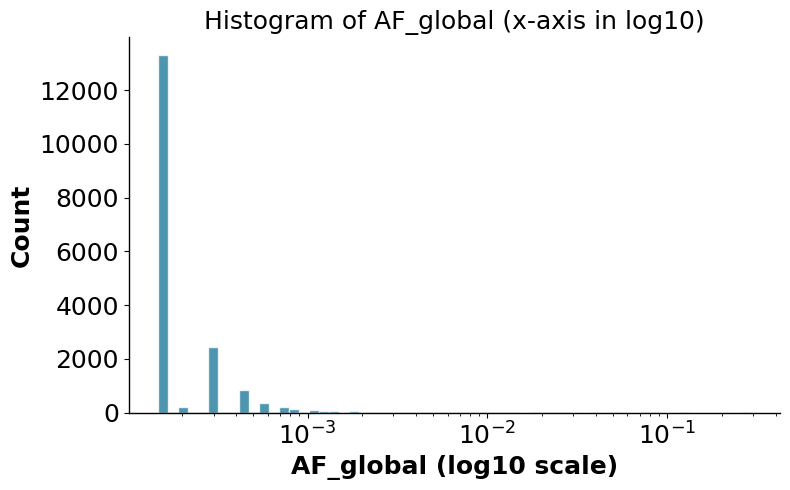

Plotted 18,075 variants with AF_global > 0
Excluded 541,986 rows with AF_global <= 0


In [70]:
fig, ax, af, af_pos = plot_af_global_histogram(freq_1kg_HGDP_table)
print(f"Plotted {len(af_pos):,} variants with AF_global > 0")
print(f"Excluded {(af <= 0).sum():,} rows with AF_global <= 0")

In [71]:
validation_rows, library_alleles, alleles_lifted, freq_found = build_validation_rows(
    library_design_df=library_design,
    positions_bed_lift_df=positions_bed_lift,
    freq_table=freq_1kg_HGDP_table,
)

print(f"library_alleles rows: {len(library_alleles):,}")
print(f"freq_found rows: {len(freq_found):,}")
print(f"validation_rows rows: {len(validation_rows):,}")

library_alleles rows: 574,290
freq_found rows: 18,753
validation_rows rows: 18,753


In [73]:
analysis_rows, derived_ref_alt_summary, derived_alt_frequency_table = summarize_hmpra_derived_alleles(
    validation_rows_df=validation_rows,
 )

# Console summary
total_compared = len(analysis_rows)
ref_n = int((analysis_rows["hMPRA_role_in_1kg"] == "REF").sum())
alt_n = int((analysis_rows["hMPRA_role_in_1kg"] == "ALT").sum())
neither_n = int((analysis_rows["hMPRA_role_in_1kg"] == "NEITHER").sum())

print("hMPRA derived allele REF/ALT analysis (all usable validation_rows)")
print("=" * 80)
print(f"Usable rows analyzed: {total_compared:,}")
print(f"Identified as REF: {ref_n:,} ({(100 * ref_n / total_compared) if total_compared else np.nan:.2f}%)")
print(f"Identified as ALT: {alt_n:,} ({(100 * alt_n / total_compared) if total_compared else np.nan:.2f}%)")
print(f"Identified as NEITHER: {neither_n:,} ({(100 * neither_n / total_compared) if total_compared else np.nan:.2f}%)")
print()
print("Summary table: derived_ref_alt_summary")
print(derived_ref_alt_summary.to_string(index=False, float_format=lambda x: f"{x:,.6f}"))
print()
print(f"ALT frequency table rows: {len(derived_alt_frequency_table):,}")
print("Table name: derived_alt_frequency_table")
derived_alt_frequency_table

hMPRA derived allele REF/ALT analysis (all usable validation_rows)
Usable rows analyzed: 17,105
Identified as REF: 17,096 (99.95%)
Identified as ALT: 0 (0.00%)
Identified as NEITHER: 9 (0.05%)

Summary table: derived_ref_alt_summary
hMPRA_role_in_1kg  n_rows  mean_hMPRA_derived_allele_frequency  median_hMPRA_derived_allele_frequency  percent_of_rows
              REF   17096                             0.999754                               0.999852        99.947384
              ALT       0                                  NaN                                    NaN         0.000000
          NEITHER       9                                  NaN                                    NaN         0.052616

ALT frequency table rows: 0
Table name: derived_alt_frequency_table


,hg38_chr,hg38_start,hg38_end,variant_token,hMPRA_derived_allele,ref_base,alt_base,alt_allele_frequency_1kg,hMPRA_derived_allele_frequency_1kg


# Do the differentially active oligos overlap with cartilage eQTLs?

#### Read eQTL data

In [116]:
high_grade_cartilage_eQTLs = pd.read_csv("/home/labs/davidgo/Collaboration/USEFUL_DATASETS/Expression/Cartilage/Human/cartilage_eQTLs_for_healthy_and_OA_individuals/processed_data/HighGradeCartilage_significant_eQTLs.txt", sep="\t")
low_grade_cartilage_eQTLs = pd.read_csv("/home/labs/davidgo/Collaboration/USEFUL_DATASETS/Expression/Cartilage/Human/cartilage_eQTLs_for_healthy_and_OA_individuals/processed_data/LowGradeCartilage_significant_eQTLs.txt", sep="\t")

high_grade_cartilage_eQTLs["origin"] = "high_grade"
low_grade_cartilage_eQTLs["origin"] = "low_grade"

cartilage_eQTLs = pd.concat(
    [high_grade_cartilage_eQTLs, low_grade_cartilage_eQTLs],
    ignore_index=True
)

In [117]:
cartilage_eQTLs["chromosome"] = cartilage_eQTLs["genotype_id"].apply(lambda x: x.split(":")[0])
cartilage_eQTLs["position"] = cartilage_eQTLs["genotype_id"].apply(lambda x: int(x.split(":")[1]))

In [118]:
cartilage_eQTLs

,genotype_id,phenotype_id,targetDistances,pval,slope,slope_se,PERM_num_var,PERM_beta_shape1,PERM_beta_shape2,PERM_true_df,...,PERM_qval,PERM_pval_nominal_threshold,eGeneVariant,eGene,REF,ALT,INFO,origin,chromosome,position
0,1:10190884,PGD_ENSG00000142657,-268254,3.059310e-07,0.721159,0.128416,2476,1.06054,168.073,63.5164,...,8.232830e-15,0.000062,1,1,A,T,AF=0.33473;MAF=0.33473;R2=0.85773,high_grade,1,10190884
1,1:10209557,PGD_ENSG00000142657,-249581,6.228250e-07,0.719082,0.132165,2476,1.06054,168.073,63.5164,...,8.232830e-15,0.000062,1,1,A,G,AF=0.21218;MAF=0.21218;R2=0.86767,high_grade,1,10209557
2,1:10214442,PGD_ENSG00000142657,-244696,6.485170e-07,0.715892,0.131822,2476,1.06054,168.073,63.5164,...,8.232830e-15,0.000062,1,1,T,A,AF=0.21172;MAF=0.21172;R2=0.87519,high_grade,1,10214442
3,1:10235712,PGD_ENSG00000142657,-223426,3.638180e-11,0.790359,0.102266,2476,1.06054,168.073,63.5164,...,8.232830e-15,0.000062,1,1,T,A,AF=0.37787;MAF=0.37787;R2=0.91237,high_grade,1,10235712
4,1:10235946,PGD_ENSG00000142657,-223192,3.248020e-08,0.737648,0.119821,2476,1.06054,168.073,63.5164,...,8.232830e-15,0.000062,1,1,T,C,AF=0.28978;MAF=0.28978;R2=0.89947,high_grade,1,10235946
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
278556,9:94864754,SPTLC1_ENSG00000090054,-12905,3.565540e-07,0.565168,0.100194,3955,1.04312,138.188,55.4891,...,3.429440e-03,0.000052,1,1,A,C,AF=0.16213;MAF=0.16213;R2=0.99834,low_grade,9,94864754
278557,9:94870152,SPTLC1_ENSG00000090054,-7507,3.446120e-07,0.583293,0.103249,3955,1.04312,138.188,55.4891,...,3.429440e-03,0.000052,1,1,C,A,AF=0.16179;MAF=0.16179;R2=0.9846,low_grade,9,94870152
278558,9:94877836,SPTLC1_ENSG00000090054,177,3.950080e-07,0.602932,0.107382,3955,1.04312,138.188,55.4891,...,3.429440e-03,0.000052,1,1,A,G,AF=0.16133;MAF=0.16133;R2=0.97533,low_grade,9,94877836
278559,9:94914307,SPTLC1_ENSG00000090054,36648,4.312560e-05,0.364777,0.083421,3955,1.04312,138.188,55.4891,...,3.429440e-03,0.000052,1,1,A,G,AF=0.33253;MAF=0.33253;R2=0.94829,low_grade,9,94914307


#### Read hMPRA data

In [147]:
# Read only the specified columns from the CSV file
oligos = pd.read_csv(f'/home/labs/davidgo/Collaboration/humanMPRA/top_candidates/chondrocytes/humanMPRA_annotations_v3.csv', 
                     #usecols=range(0, 25), 
                     header=0)
print('Number of oligos in hMPRA:', len(oligos))
oligos = oligos.drop_duplicates(subset=["oligo"], keep = "first") #There are several HH oligos which are duplicated
print('Number of oligos in hMPRA without duplicates:', len(oligos))

min_DNA_counts = 50

oligos = oligos[(oligos['DNA_counts_raw_derived']>min_DNA_counts) &
                               (oligos['DNA_counts_raw_ancestral']>min_DNA_counts)]
print('Number of oligos in hMPRA after filtering for at least 50 DNA counts in both archaic and derived:', len(oligos))


ATAC_seq_filter = True
ATAC_seq_distance = 5000

if ATAC_seq_filter:
    print('Number of oligos in hMPRA before filtering for being in an ATAC-seq peak:', len(oligos))
    oligos["ATAC_seq_bool"] = oligos["ATACseq_peaks_fetal_chondrocytes"].abs() < ATAC_seq_distance
    oligos = oligos[oligos["ATAC_seq_bool"] == True]
    print('Number of oligos in hMPRA after filtering for being in an ATAC-seq peak:', len(oligos))


/tmp/ipykernel_28767/2285731140.py:2: DtypeWarning: Columns (34) have mixed types. Specify dtype option on import or set low_memory=False.
  oligos = pd.read_csv(f'/home/labs/davidgo/Collaboration/humanMPRA/top_candidates/chondrocytes/humanMPRA_annotations_v3.csv',


Number of oligos in hMPRA: 355898
Number of oligos in hMPRA without duplicates: 355891
Number of oligos in hMPRA after filtering for at least 50 DNA counts in both archaic and derived: 313358
Number of oligos in hMPRA before filtering for being in an ATAC-seq peak: 313358
Number of oligos in hMPRA after filtering for being in an ATAC-seq peak: 242672


Analyzing distances between oligos and cartilage eQTLs...
Number of cartilage eQTLs: 278561
Oligos with eQTL distance data (diff_vs_active): 42386


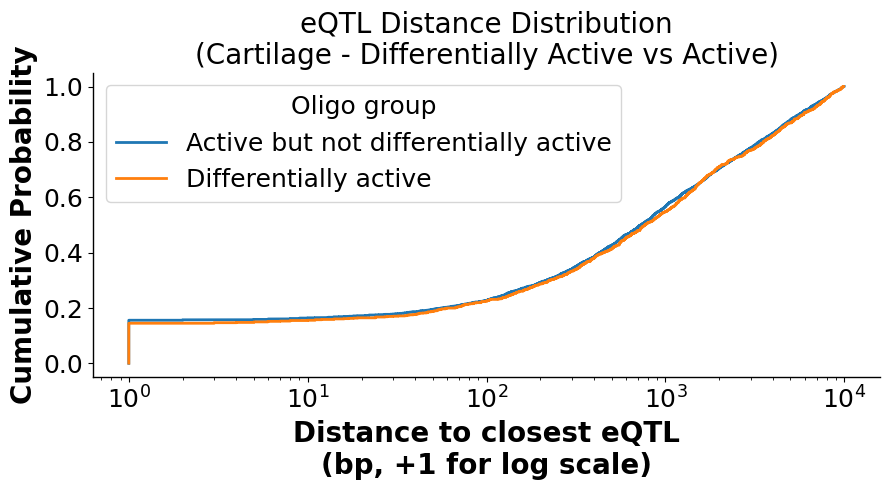

Summary statistics by group:
                                       count         mean          std  min  \
group                                                                         
Active but not differentially active  3337.0  1803.078214  2376.040307  0.0   
Differentially active                 1021.0  1869.257591  2441.641704  0.0   

                                        25%    50%     75%     max  
group                                                               
Active but not differentially active  128.0  729.0  2553.0  9987.0  
Differentially active                 140.0  766.0  2704.0  9915.0  

Kolmogorov-Smirnov Test: Compare eQTL distance distributions

Group 1: Active but not differentially active
  N = 3337, Mean = 1803.1 bp, Median = 729.0 bp

Group 2: Differentially active
  N = 1021, Mean = 1869.3 bp, Median = 766.0 bp

Kolmogorov-Smirnov Test:
  Test statistic = 0.0248
  P-value = 7.0935e-01
  ✗ No significant difference (p >= 0.05): Distributions are not s

In [148]:
# Define the distance calculation function for eQTLs
def calculate_eqtl_distances(oligos_df, eqtl_df,
                            oligo_chr_col="chromosome",
                            oligo_start_col="start",
                            oligo_end_col="end",
                            oligo_activity_col="differential_activity",
                            eqtl_chr_col="chromosome",
                            eqtl_pos_col="position",
                            output_dist_col="nearest_eqtl_distance_bp",
                            activity_type="diff_vs_active",
                            group_labels=None):
    """
    Calculate distance from each oligo to the nearest eQTL.
    
    Parameters:
    -----------
    oligos_df : DataFrame
        Oligo dataframe with coordinates and activity labels
    eqtl_df : DataFrame
        eQTL dataframe with SNP positions
    oligo_chr_col : str
        Chromosome column name in oligos_df
    oligo_start_col : str
        Start coordinate column in oligos_df
    oligo_end_col : str
        End coordinate column in oligos_df
    oligo_activity_col : str
        Differential activity column in oligos_df
    eqtl_chr_col : str
        Chromosome column name in eqtl_df
    eqtl_pos_col : str
        Position column in eqtl_df
    output_dist_col : str
        Name for output distance column
    activity_type : str
        Type of comparison: "diff_vs_active" (default) compares differentially active vs active but not differentially active.
        "active_vs_non_active" compares all active oligos vs non-active oligos (with NA values).
    group_labels : dict
        Dict mapping group values to labels. If None, uses defaults based on activity_type.
    
    Returns:
    --------
    DataFrame with distances and activity group labels
    """
    
    if activity_type not in ["diff_vs_active", "active_vs_non_active"]:
        raise ValueError(f"activity_type must be 'diff_vs_active' or 'active_vs_non_active', got {activity_type}")
    
    # Prepare oligo data
    oligos_dist = oligos_df.copy()
    cols_needed = [oligo_chr_col, oligo_start_col, oligo_end_col, oligo_activity_col]
    missing = [c for c in cols_needed if c not in oligos_dist.columns]
    if missing:
        raise ValueError(f"Missing required oligos columns: {missing}")
    
    # For coordinates, we need chr/start/end to be non-null
    oligos_dist = oligos_dist[[oligo_chr_col, oligo_start_col, oligo_end_col, oligo_activity_col]].copy()
    oligos_dist[oligo_start_col] = pd.to_numeric(oligos_dist[oligo_start_col], errors="coerce")
    oligos_dist[oligo_end_col] = pd.to_numeric(oligos_dist[oligo_end_col], errors="coerce")
    oligos_dist = oligos_dist.dropna(subset=[oligo_chr_col, oligo_start_col, oligo_end_col]).copy()
    oligos_dist[oligo_start_col] = oligos_dist[oligo_start_col].astype(int)
    oligos_dist[oligo_end_col] = oligos_dist[oligo_end_col].astype(int)
    oligos_dist["chrom_clean"] = oligos_dist[oligo_chr_col].astype(str).str.replace("^chr", "", regex=True)
    
    # Prepare eQTL data
    eqtl_proc = eqtl_df.copy()
    missing_eqtl = [c for c in [eqtl_chr_col, eqtl_pos_col] if c not in eqtl_proc.columns]
    if missing_eqtl:
        raise ValueError(f"Missing required eQTL columns: {missing_eqtl}")
    
    eqtl_proc = eqtl_proc[[eqtl_chr_col, eqtl_pos_col]].dropna().copy()
    eqtl_proc[eqtl_pos_col] = pd.to_numeric(eqtl_proc[eqtl_pos_col], errors="coerce")
    eqtl_proc = eqtl_proc.dropna(subset=[eqtl_pos_col]).copy()
    eqtl_proc[eqtl_pos_col] = eqtl_proc[eqtl_pos_col].astype(int)
    eqtl_proc["chrom_clean"] = eqtl_proc[eqtl_chr_col].astype(str).str.replace("^chr", "", regex=True)
    
    # Compute distance from oligo interval (distance = 0 if eQTL falls within oligo)
    nearest_distances = []
    for chrom, grp in oligos_dist.groupby("chrom_clean"):
        eqtl_pos = np.sort(eqtl_proc.loc[eqtl_proc["chrom_clean"] == chrom, eqtl_pos_col].values)
        
        starts = grp[oligo_start_col].to_numpy()
        ends = grp[oligo_end_col].to_numpy()

        if len(eqtl_pos) == 0:
            nearest = np.full(len(starts), np.nan)
        else:
            nearest = np.zeros(len(starts))
            
            for i in range(len(starts)):
                start = starts[i]
                end = ends[i]
                
                eqtls_inside = np.sum((eqtl_pos >= start) & (eqtl_pos <= end))
                if eqtls_inside > 0:
                    nearest[i] = 0
                else:
                    idx_left = np.searchsorted(eqtl_pos, start, side='right') - 1
                    idx_right = np.searchsorted(eqtl_pos, end, side='left')
                    
                    left_dist = np.inf
                    right_dist = np.inf
                    
                    if idx_left >= 0:
                        left_dist = start - eqtl_pos[idx_left]
                    if idx_right < len(eqtl_pos):
                        right_dist = eqtl_pos[idx_right] - end
                    
                    nearest[i] = min(left_dist, right_dist)

        out = grp.copy()
        out[output_dist_col] = nearest
        nearest_distances.append(out)

    result = pd.concat(nearest_distances, ignore_index=True)
    result = result.dropna(subset=[output_dist_col]).copy()

    # Handle activity classification based on activity_type
    if activity_type == "diff_vs_active":
        # Compare differentially active vs active but not differentially active
        # Keep only rows with explicit TRUE/FALSE values
        status_map = {
            True: True, False: False,
            "TRUE": True, "FALSE": False,
            "True": True, "False": False,
            "true": True, "false": False,
            1: True, 0: False
        }
        result["diff_bool"] = result[oligo_activity_col].map(status_map)
        result = result[result["diff_bool"].isin([True, False])].copy()

        # Create group labels
        if group_labels is None:
            group_labels = {True: "Differentially active", False: "Active but not differentially active"}
        
        result["group"] = result["diff_bool"].map(group_labels)

    elif activity_type == "active_vs_non_active":
        # Compare non-NaN values (active) vs NaN values (non-active)
        # Keep both groups - do NOT filter out rows since NaN distinction is important
        result["is_nan"] = result[oligo_activity_col].isna()
        
        # Create group labels
        if group_labels is None:
            group_labels = {False: "Active", True: "Non-active"}  # False = not NaN = active; True = NaN = non-active
        
        result["group"] = result["is_nan"].map(group_labels)
        
    return result


def plot_ecdf_with_ks_test(plot_df,
                          distance_col="nearest_eqtl_distance_bp",
                          group_col="group",
                          figsize=(9, 5),
                          title_suffix="",
                          max_distance=10000,
                          downsample=False):
    """
    Plot ECDF of SNP distances and perform Kolmogorov-Smirnov test.
    
    Parameters:
    -----------
    plot_df : DataFrame
        DataFrame with distance and group columns (output from calculate_eqtl_distances)
    distance_col : str
        Name of distance column
    group_col : str
        Name of group/category column
    figsize : tuple
        Figure size
    title_suffix : str
        Suffix for figure title
    max_distance : int
        Maximum distance in base pairs to include in analysis (default: 10000).
        Values above this threshold will be filtered out.
    downsample : bool
        If True, downsample the larger group to match the size of the smaller group (default: False).
    
    Returns:
    --------
    K-S test results as dictionary
    """
    
    # Filter data by max_distance
    plot_df_filtered = plot_df[plot_df[distance_col] <= max_distance].copy()
    
    # Downsample larger group if requested
    if downsample:
        group_sizes = plot_df_filtered[group_col].value_counts()
        min_size = group_sizes.min()
        
        # Downsample each group to min_size
        downsampled_groups = []
        for group_name in plot_df_filtered[group_col].unique():
            group_data = plot_df_filtered[plot_df_filtered[group_col] == group_name]
            if len(group_data) > min_size:
                group_data = group_data.sample(n=min_size, random_state=42)
            downsampled_groups.append(group_data)
        
        plot_df_filtered = pd.concat(downsampled_groups, ignore_index=True)
    
    # ECDF plot
    plt.figure(figsize=figsize)

    for group, grp in plot_df_filtered.groupby(group_col):
        x = grp[distance_col].to_numpy(dtype=float)
        x = x[np.isfinite(x)]
        x = np.sort(x)

        if x.size == 0:
            continue

        y = np.arange(1, x.size + 1) / x.size

        # +1 avoids log(0) issues while preserving ordering
        plt.step(x + 1, y, where="post", label=group, linewidth=2)

    plt.xscale("log")
    plt.xlabel(f"Distance to closest eQTL\n(bp, +1 for log scale)")
    plt.ylabel("Cumulative Probability")
    plt.legend(title="Oligo group")
    if title_suffix:
        plt.title(f"eQTL Distance Distribution\n{title_suffix}")
    plt.tight_layout()
    plt.show()

    # Quick summary stats
    print("Summary statistics by group:")
    print(plot_df_filtered.groupby(group_col)[distance_col].describe())

    # Kolmogorov-Smirnov test
    print("\n" + "="*70)
    print("Kolmogorov-Smirnov Test: Compare eQTL distance distributions")
    print("="*70)

    groups = plot_df_filtered[group_col].unique()
    ks_results = {}
    
    if len(groups) == 2:
        group1_data = plot_df_filtered[plot_df_filtered[group_col] == groups[0]][distance_col].dropna().values
        group2_data = plot_df_filtered[plot_df_filtered[group_col] == groups[1]][distance_col].dropna().values
        
        ks_stat, ks_pvalue = stats.ks_2samp(group1_data, group2_data)
        
        print(f"\nGroup 1: {groups[0]}")
        print(f"  N = {len(group1_data)}, Mean = {np.mean(group1_data):.1f} bp, Median = {np.median(group1_data):.1f} bp")
        print(f"\nGroup 2: {groups[1]}")
        print(f"  N = {len(group2_data)}, Mean = {np.mean(group2_data):.1f} bp, Median = {np.median(group2_data):.1f} bp")
        print(f"\nKolmogorov-Smirnov Test:")
        print(f"  Test statistic = {ks_stat:.4f}")
        print(f"  P-value = {ks_pvalue:.4e}")
        
        if ks_pvalue < 0.05:
            print(f"  ✓ Significant difference (p < 0.05): Distributions are significantly different")
        else:
            print(f"  ✗ No significant difference (p >= 0.05): Distributions are not significantly different")
        
        ks_results = {
            "group1": groups[0],
            "group2": groups[1],
            "n_group1": len(group1_data),
            "n_group2": len(group2_data),
            "mean_group1": np.mean(group1_data),
            "mean_group2": np.mean(group2_data),
            "median_group1": np.median(group1_data),
            "median_group2": np.median(group2_data),
            "ks_statistic": ks_stat,
            "ks_pvalue": ks_pvalue,
            "significant": ks_pvalue < 0.05
        }
    else:
        print(f"Warning: Expected 2 groups, found {len(groups)}")
    
    return ks_results


# Calculate distances from oligos to cartilage eQTLs (diff vs active comparison)
print("Analyzing distances between oligos and cartilage eQTLs...")
print(f"Number of cartilage eQTLs: {len(cartilage_eQTLs)}")

eqtl_plot_df = calculate_eqtl_distances(
    oligos,
    cartilage_eQTLs,
    oligo_chr_col="chromosome",
    oligo_start_col="start",
    oligo_end_col="end",
    oligo_activity_col="differential_activity",
    eqtl_chr_col="chromosome",
    eqtl_pos_col="position",
    output_dist_col="nearest_eqtl_distance_bp",
    activity_type="diff_vs_active"
)

print(f"Oligos with eQTL distance data (diff_vs_active): {len(eqtl_plot_df)}")

# Create ECDF plot and run K-S test for cartilage eQTLs
eqtl_ks_results = plot_ecdf_with_ks_test(
    eqtl_plot_df,
    distance_col="nearest_eqtl_distance_bp",
    group_col="group",
    title_suffix="(Cartilage - Differentially Active vs Active)",downsample=False
)


Comparing all active oligos vs non-active oligos...
Oligos with eQTL distance data (active_vs_non_active): 238952


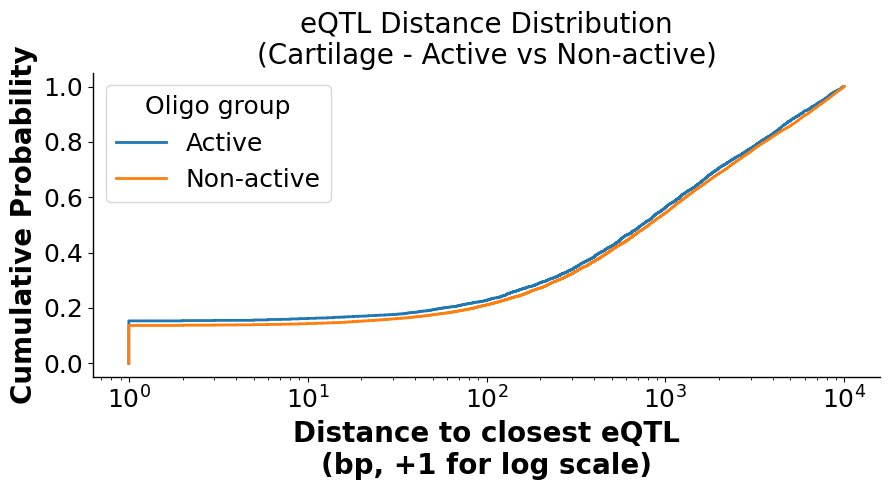

Summary statistics by group:
              count         mean          std  min    25%    50%     75%  \
group                                                                      
Active       4358.0  1818.582836  2391.452718  0.0  129.0  736.5  2578.0   
Non-active  19402.0  1945.580146  2508.006815  0.0  161.0  809.0  2770.0   

                max  
group                
Active       9987.0  
Non-active  10000.0  

Kolmogorov-Smirnov Test: Compare eQTL distance distributions

Group 1: Non-active
  N = 19402, Mean = 1945.6 bp, Median = 809.0 bp

Group 2: Active
  N = 4358, Mean = 1818.6 bp, Median = 736.5 bp

Kolmogorov-Smirnov Test:
  Test statistic = 0.0219
  P-value = 6.5224e-02
  ✗ No significant difference (p >= 0.05): Distributions are not significantly different


In [153]:
# Now compare all active oligos vs non-active oligos
print("\n" + "="*80)
print("Comparing all active oligos vs non-active oligos...")
print("="*80)

eqtl_plot_df_active_vs_non = calculate_eqtl_distances(
    oligos,
    cartilage_eQTLs,
    oligo_chr_col="chromosome",
    oligo_start_col="start",
    oligo_end_col="end",
    oligo_activity_col="differential_activity",
    eqtl_chr_col="chromosome",
    eqtl_pos_col="position",
    output_dist_col="nearest_eqtl_distance_bp",
    activity_type="active_vs_non_active"
)

print(f"Oligos with eQTL distance data (active_vs_non_active): {len(eqtl_plot_df_active_vs_non)}")

# Create ECDF plot and run K-S test for active vs non-active
eqtl_ks_results_active_vs_non = plot_ecdf_with_ks_test(
    eqtl_plot_df_active_vs_non,
    distance_col="nearest_eqtl_distance_bp",
    group_col="group",
    title_suffix="(Cartilage - Active vs Non-active)",
    max_distance=10000
)

Analyzing distances between oligos and cartilage eQTLs...
Number of cartilage eQTLs: 278561
Oligos with eQTL distance data: 42386


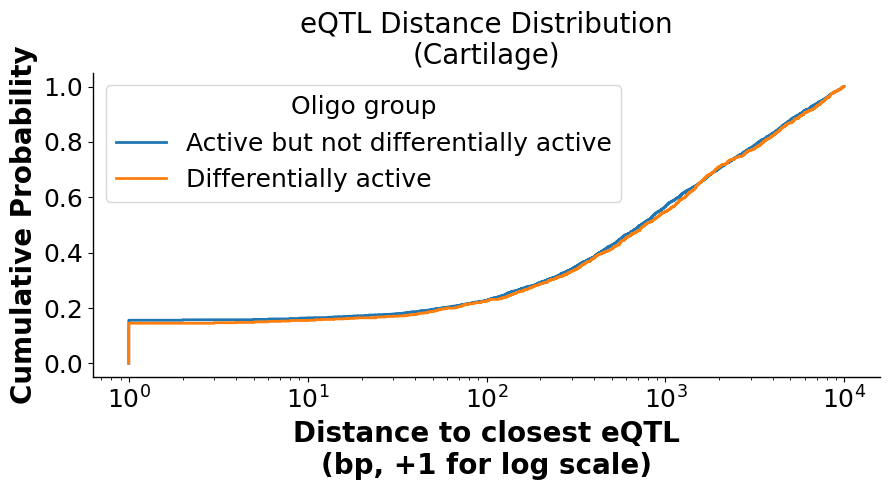

Summary statistics by group:
                                       count         mean          std  min  \
group                                                                         
Active but not differentially active  3337.0  1803.078214  2376.040307  0.0   
Differentially active                 1021.0  1869.257591  2441.641704  0.0   

                                        25%    50%     75%     max  
group                                                               
Active but not differentially active  128.0  729.0  2553.0  9987.0  
Differentially active                 140.0  766.0  2704.0  9915.0  

Kolmogorov-Smirnov Test: Compare eQTL distance distributions

Group 1: Active but not differentially active
  N = 3337, Mean = 1803.1 bp, Median = 729.0 bp

Group 2: Differentially active
  N = 1021, Mean = 1869.3 bp, Median = 766.0 bp

Kolmogorov-Smirnov Test:
  Test statistic = 0.0248
  P-value = 7.0935e-01
  ✗ No significant difference (p >= 0.05): Distributions are not s

In [152]:
# Create ECDF plot and run K-S test for cartilage eQTLs
# Calculate distances from oligos to cartilage eQTLs
print("Analyzing distances between oligos and cartilage eQTLs...")
print(f"Number of cartilage eQTLs: {len(cartilage_eQTLs)}")

eqtl_plot_df = calculate_eqtl_distances(
    oligos,
    cartilage_eQTLs,
    oligo_chr_col="chromosome",
    oligo_start_col="start",
    oligo_end_col="end",
    oligo_activity_col="differential_activity",
    eqtl_chr_col="chromosome",
    eqtl_pos_col="position",
    output_dist_col="nearest_eqtl_distance_bp"
)

print(f"Oligos with eQTL distance data: {len(eqtl_plot_df)}")

eqtl_ks_results = plot_ecdf_with_ks_test(
    eqtl_plot_df,
    distance_col="nearest_eqtl_distance_bp",
    group_col="group",
    title_suffix="(Cartilage)",
    max_distance=10000
)

## Comparing the activity of the Osteochondral progenitor cells to the chondroycts

### Load the articular cartilage TPM

In [37]:
gene_annotation_table = pd.read_csv('/home/labs/davidgo/nadavmi/usefull/Human.GRCh38.p13.annot.tsv', 
                     header=0,sep = '\t',usecols=[0,1])

articular_cartilage_TPM = pd.read_csv('/home/labs/davidgo/Collaboration/USEFUL_DATASETS/Expression/Cartilage/Human/GSE114007_human_control_and_osteoarithritis_cartilage/GSE114007_norm_counts_TPM_GRCh38.p13_NCBI.tsv', 
                     header=0,sep = '\t')

articular_cartilage_TPM = articular_cartilage_TPM.iloc[:,0:9]
articular_cartilage_TPM['articular_cartilage_mean'] = articular_cartilage_TPM.iloc[:, 1:].mean(axis=1)
articular_cartilage_TPM = articular_cartilage_TPM[['GeneID','articular_cartilage_mean']]


articular_cartilage_TPM = pd.merge(articular_cartilage_TPM, gene_annotation_table, on='GeneID', how='outer') 
articular_cartilage_TPM = articular_cartilage_TPM.set_index('Symbol')
articular_cartilage_TPM = articular_cartilage_TPM[['articular_cartilage_mean']]
articular_cartilage_TPM = articular_cartilage_TPM.groupby('Symbol', as_index=True).mean() # Group by gene name and average duplicates


### Load the hybrids TPM

In [44]:
hybrid_data = pd.read_csv(f"/home/labs/davidgo/Collaboration/USEFUL_DATASETS/Expression/Hybrids/human_chimp/ExpLBM/outputs_05Jan2026_humanMPRA_draft1/ExpLBM_polarization_results.tsv", 
                     sep = '\t',
                     header=0)
hybrid_data = hybrid_data[hybrid_data['Gene'].notna()]
hybrid_data['ASE_full'] = hybrid_data['ExpLBM_gene_ase_type']+'_'+hybrid_data['derived']

In [69]:
hybrid_data

,Gene,ExpLBM_TPM_human_allele,ExpLBM_TPM_human_allele_HG,ExpLBM_TPM_chimp_allele,ExpLBM_TPM_gorilla_allele,ExpLBM_TPM_total,ExpLBM_log2TPM_human_allele,ExpLBM_log2TPM_human_allele_HG,ExpLBM_log2TPM_chimp_allele,ExpLBM_log2TPM_gorilla_allele,...,ExpLBM_LFC_padj_human_ref,ExpLBM_LFC_chimp_ref,ExpLBM_LFC_padj_chimp_ref,ExpLBM_gene_ase_type,d_GH,d_GC,G_clipped,human_derived_score,derived,ASE_full
0,A1BG,0.589528,0.851414,0.527905,1.412338,2.210705,0.668598,0.888627,0.611555,1.270432,...,0.394157,0.268019,0.307232,nonASE,0.601834,0.658877,0.589528,-1.000000,chimp-derived,nonASE_chimp-derived
1,A2M,1.409486,1.597975,1.120505,1.318553,4.860193,1.268725,1.377387,1.084408,1.213224,...,0.011117,0.278937,0.053456,nonASE,0.055501,0.128817,1.318553,-0.370662,chimp-derived,nonASE_chimp-derived
2,A2MP1,0.011313,0.030674,0.016085,0.006907,0.036106,0.016230,0.043588,0.023021,0.009931,...,0.848341,0.205740,0.684719,else,0.006299,0.013090,0.011313,-1.000000,chimp-derived,else_chimp-derived
3,NAT1,2.001059,2.470029,1.603822,1.688204,3.989507,1.585472,1.794948,1.380631,1.426642,...,0.014630,0.434379,0.001459,ASE,0.158829,0.046012,1.688204,0.575156,human-derived,ASE_human-derived
4,NAT2,0.573581,0.901408,0.655862,0.828586,1.762164,0.654052,0.927068,0.727582,0.870728,...,0.687675,0.080235,0.856452,else,0.216677,0.143146,0.655862,1.000000,human-derived,else_human-derived
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
92614,bP-2189O9.5,0.010645,0.000000,0.008531,0.000000,0.045655,0.015276,0.000000,0.012255,0.000000,...,NaN,NaN,NaN,else,0.015276,0.012255,0.008531,1.000000,human-derived,else_human-derived
92615,hsa-mir-1253,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,NaN,NaN,NaN,else,0.000000,0.000000,0.000000,NaN,NaN,NaN
92616,hsa-mir-423,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,NaN,NaN,NaN,else,0.000000,0.000000,0.000000,NaN,NaN,NaN
92617,snoZ196,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,NaN,NaN,NaN,else,0.000000,0.000000,0.000000,NaN,NaN,NaN


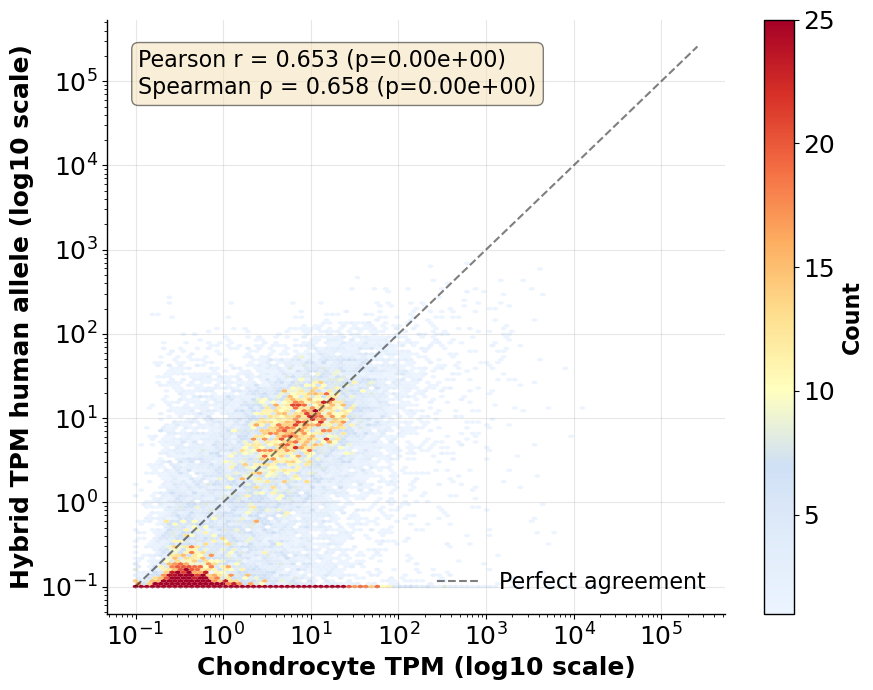

Comparison complete: 26541 genes with TPM data in both datasets
Pearson correlation (log10): r=0.6535, p=0.00e+00
Spearman correlation: ρ=0.6579, p=0.00e+00


In [73]:
# Compare TPM in chondrocytes vs hybrids
# Merge data by gene name
comparison_df = articular_cartilage_TPM.reset_index().rename(columns={'Symbol': 'Gene', 'articular_cartilage_mean': 'chond_TPM'})
comparison_df = comparison_df.merge(
    hybrid_data[['Gene', 'ExpLBM_TPM_human_allele']].drop_duplicates(subset=['Gene'], keep='first'),
    on='Gene',
    how='inner'
)
comparison_df = comparison_df.dropna(subset=['chond_TPM', 'ExpLBM_TPM_human_allele'])

# Create hexbin plot comparing TPM values
fig, ax = plt.subplots(figsize=(9, 7))

# Add pseudocount of 0.1 to avoid log(0) issues
x_data = comparison_df['chond_TPM'].values + 0.1
y_data = comparison_df['ExpLBM_TPM_human_allele'].values + 0.1

# Create hexbin plot with log scale
hb = ax.hexbin(x_data, y_data, gridsize=100, xscale='log', yscale='log', linewidths=0,
               cmap=custom_cmap, mincnt=1, vmax=25)

# Add diagonal reference line
min_val = min(x_data.min(), y_data.min())
max_val = max(x_data.max(), y_data.max())
ax.plot([min_val, max_val], [min_val, max_val], 'k--', linewidth=1.5, alpha=0.5, label='Perfect agreement')

# Calculate correlation
from scipy.stats import pearsonr, spearmanr
pearson_r, pearson_p = pearsonr(np.log10(x_data), np.log10(y_data))
spearman_r, spearman_p = spearmanr(x_data, y_data)

ax.set_xlabel('Chondrocyte TPM (log10 scale)', fontsize=FONT_SIZE_small)
ax.set_ylabel('Hybrid TPM human allele (log10 scale)', fontsize=FONT_SIZE_small)
#ax.set_title(f'TPM Comparison: Chondrocytes vs Hybrids\n(n={len(comparison_df)} genes)', fontsize=FONT_SIZE_small)
ax.legend(frameon=False, fontsize=FONT_SIZE_small-2, loc='lower right')
ax.grid(True, alpha=0.3)

# Add colorbar
cb = plt.colorbar(hb, ax=ax)
cb.set_label('Count', fontsize=FONT_SIZE_small-2)

# Add correlation text
textstr = f'Pearson r = {pearson_r:.3f} (p={pearson_p:.2e})\nSpearman ρ = {spearman_r:.3f} (p={spearman_p:.2e})'
ax.text(0.05, 0.95, textstr, transform=ax.transAxes, fontsize=FONT_SIZE_small-2,
        verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.savefig(output_path + 'chondrocytes_vs_hybrids_TPM_comparison.pdf', bbox_inches='tight', dpi=300)
plt.savefig(output_path + 'chondrocytes_vs_hybrids_TPM_comparison.png', bbox_inches='tight', dpi=300)
plt.show()

print(f"Comparison complete: {len(comparison_df)} genes with TPM data in both datasets")
print(f"Pearson correlation (log10): r={pearson_r:.4f}, p={pearson_p:.2e}")
print(f"Spearman correlation: ρ={spearman_r:.4f}, p={spearman_p:.2e}")

In [75]:
pwd

'/home/labs/davidgo/Collaboration/backup/humanMPRA/scripts/produce_paper_figures'

# Correlation in RNA-seq between chondrocytes, osteochondral progenitors and cartilage organoids

In [2]:
#Take colnames from Yamada table
Yamada_raw = pd.read_excel(f'/home/labs/davidgo/Collaboration/USEFUL_DATASETS/Expression/Cartilage/Human/GSE165620_Yamada_differentiation_protocol/GSE165620_hiPSC_RNAseq_raw_data.xlsx', 
                     nrows = 1,
                     header=0)
steps_names = Yamada_raw.columns

# Take normalized TPM values from NCBI
Yamada_TPM = pd.read_csv(f'/home/labs/davidgo/Collaboration/USEFUL_DATASETS/Expression/Cartilage/Human/GSE165620_Yamada_differentiation_protocol/GSE165620_norm_counts_TPM_GRCh38.p13_NCBI.tsv',
                         sep = '\t',
                         header=0)
Yamada_TPM.columns = steps_names

# Convert gene IDs to gene names
GRCh38_annotation = pd.read_csv(f'/home/labs/davidgo/Collaboration/GenomeAnnotation/Human/NCBI/hg38/old/Human.GRCh38.p13.annot.tsv',
                         sep = '\t',
                         header=0)

GRCh38_annotation = GRCh38_annotation[['GeneID','Symbol']]
Yamada_TPM = GRCh38_annotation.merge(
    Yamada_TPM,
    left_on="GeneID",   # column in Yamada_TPM
    right_on="Geneid",  # column in GRCh38_annotation
    how="right"          # or "inner", depending on what you want
)

/tmp/ipykernel_155580/3915619471.py:14: DtypeWarning: Columns (8,9) have mixed types. Specify dtype option on import or set low_memory=False.
  GRCh38_annotation = pd.read_csv(f'/home/labs/davidgo/Collaboration/GenomeAnnotation/Human/NCBI/hg38/old/Human.GRCh38.p13.annot.tsv',


#### Also add the articular cartilage chondrocytes from a different source:

In [8]:
articular_cartilage_TPM = pd.read_csv('/home/labs/davidgo/Collaboration/USEFUL_DATASETS/Expression/Cartilage/Human/GSE114007_human_control_and_osteoarithritis_cartilage/GSE114007_norm_counts_TPM_GRCh38.p13_NCBI.tsv', 
                     header=0,sep = '\t')

articular_cartilage_TPM = articular_cartilage_TPM.iloc[:,0:9]
articular_cartilage_TPM['articular_cartilage_mean'] = articular_cartilage_TPM.iloc[:, 1:].mean(axis=1)
articular_cartilage_TPM = articular_cartilage_TPM[['GeneID','articular_cartilage_mean']]


articular_cartilage_TPM = pd.merge(articular_cartilage_TPM, GRCh38_annotation, on='GeneID', how='outer') 
articular_cartilage_TPM = articular_cartilage_TPM.set_index('Symbol')
articular_cartilage_TPM = articular_cartilage_TPM[['articular_cartilage_mean']]
articular_cartilage_TPM = articular_cartilage_TPM.groupby('Symbol', as_index=True).mean() # Group by gene name and average duplicates


In [3]:
Yamada_TPM = Yamada_TPM[['Symbol',
                         'Day 0 (PSC) #1',
                         'Day 0 (PSC) #2',
                         'Day 2 (LPM) #1',
                         'Day 2 (LPM) #2',
                         'Day 4 (LBM) #1',
                         'Day 4 (LBM) #2',
                         'ExpLBM PRRX1 High#1',
                         'ExpLBM PRRX1 High#2',
                         #'ExpLBM PRRX1 Low#1',
                         #'ExpLBM PRRX1 Low#2',
                         'ExpLBM PRRX1 high 2DCI Step 2 #1',
                         'ExpLBM PRRX1 high 2DCI Step 2 #2', 'ExpLBM PRRX1 high 3DCI Step 1 #1',
                         'ExpLBM PRRX1 high 3DCI Step 1 #2', 'ExpLBM PRRX1 high 3DCI Step 2 #1',
                         'ExpLBM PRRX1 high 3DCI Step 2 #2',
                         'ExpLBM PRRX1 high 3DCI Step 3: 6wks #1',
                         'ExpLBM PRRX1 high 3DCI Step 3: 6wks #2']]

In [4]:
rows_before = len(Yamada_TPM)

Yamada_TPM = Yamada_TPM.merge(
    articular_cartilage_TPM,
    left_on='Symbol',
    right_index=True,
    how='inner'
)

rows_after = len(Yamada_TPM)

print(f"Rows before merge: {rows_before:,}")
print(f"Rows after merge: {rows_after:,}")
print(f"Rows removed by inner join: {rows_before - rows_after:,}")

NameError: name 'articular_cartilage_TPM' is not defined

In [16]:
# Modular scatter correlation plot for any two columns in Yamada_TPM
def plot_scatter_correlation(
    df,
    x_col,
    y_col,
    pseudocount=0.1,
    log_scale=True,
    alpha=0.5,
    s=12,
    color="#227C9D",
    title=None,
    save_path=None,
):
    plot_df = df[[x_col, y_col]].copy()
    plot_df[x_col] = pd.to_numeric(plot_df[x_col], errors="coerce")
    plot_df[y_col] = pd.to_numeric(plot_df[y_col], errors="coerce")
    plot_df = plot_df.dropna()

    x = plot_df[x_col].values + pseudocount
    y = plot_df[y_col].values + pseudocount

    pearson_r, pearson_p = pearsonr(np.log10(x), np.log10(y)) if log_scale else pearsonr(x, y)
    spearman_r, spearman_p = spearmanr(x, y)

    fig, ax = plt.subplots(figsize=(8, 6))
    
    # Calculate 2D density for coloring
    from matplotlib.colors import Normalize
    from scipy.stats import gaussian_kde
    
    # Calculate density on log-transformed data if applicable
    if log_scale:
        x_for_kde = np.log10(x)
        y_for_kde = np.log10(y)
    else:
        x_for_kde = x
        y_for_kde = y
    
    xy = np.vstack([x_for_kde, y_for_kde])
    kde = gaussian_kde(xy)
    density = kde(xy)
    
    # Cap density at 1
    #density = np.minimum(density, 1)
    
    # Normalize density to [0, 1] for colormap
    norm = Normalize(vmin=density.min(), vmax=density.max())
    colors = custom_cmap_bolder(norm(density))
    
    ax.scatter(x, y, alpha=alpha, s=s, c=colors, edgecolors="none")
    
    # Add colorbar
    sm = plt.cm.ScalarMappable(cmap=custom_cmap_bolder, norm=norm)
    sm.set_array([])
    cbar = plt.colorbar(sm, ax=ax)
    cbar.set_label('Density', fontsize=FONT_SIZE_small - 2)

    if log_scale:
        ax.set_xscale("log")
        ax.set_yscale("log")

    min_val = min(x.min(), y.min())
    max_val = max(x.max(), y.max())
    ax.plot([min_val, max_val], [min_val, max_val], "k--", linewidth=1.2, alpha=0.6)

    ax.set_xlabel(x_col, fontsize=FONT_SIZE_small-2)
    ax.set_ylabel(y_col, fontsize=FONT_SIZE_small-2)
    #ax.set_title(title if title else f"{x_col} vs {y_col}", fontsize=FONT_SIZE_small)
    #ax.grid(True, alpha=0.25)

    # Format p-values, showing underflow when p-value is too small
    import sys
    pearson_p_str = f"p={pearson_p:.2e}" if pearson_p > 0 else f"p < {sys.float_info.min:.2e}"
    spearman_p_str = f"p={spearman_p:.2e}" if spearman_p > 0 else f"p < {sys.float_info.min:.2e}"
    
    textstr = (
        f"n = {len(plot_df):,}\n"
        f"Pearson's r = {pearson_r:.3f} ({pearson_p_str})\n"
        f"Spearman's ρ = {spearman_r:.3f} ({spearman_p_str})"
    )
    ax.text(
        0.03, 0.97, textstr,
        transform=ax.transAxes,
        va="top",
        fontsize=FONT_SIZE_small - 6,
        bbox=dict(boxstyle="round", facecolor="white", alpha=0.7),
    )

    
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, bbox_inches="tight", dpi=300)
    plt.show()

    return {"n": len(plot_df), "pearson_r": pearson_r, "pearson_p": pearson_p, "spearman_r": spearman_r, "spearman_p": spearman_p}



In [18]:
output_path

'/home/labs/davidgo/Collaboration/humanMPRA/paper/raw_plots/'

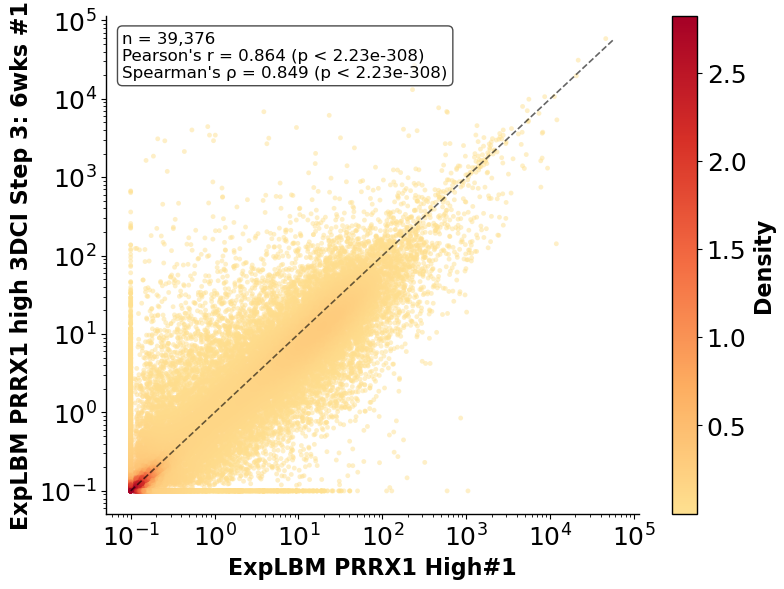

{'n': 39376, 'pearson_r': np.float64(0.8638414354711967), 'pearson_p': np.float64(0.0), 'spearman_r': np.float64(0.8490289146143839), 'spearman_p': np.float64(0.0)}


In [17]:
# Choose columns here (easy to change)
x_col = "ExpLBM PRRX1 High#1"
y_col = "ExpLBM PRRX1 high 3DCI Step 3: 6wks #1"

corr_stats = plot_scatter_correlation(
    Yamada_TPM,
    x_col=x_col,
    y_col=y_col,
    #title="Correlation between ExpLBM PRRX1 High#1 and 3DCI Step 3: 6wks #1",
    save_path=output_path + "ExpLBM_PRRX1_high_3DCI_Step_3_6wks_ExpLBM_PRRX1_High_1_scatter.png",
)

print(corr_stats)


Removed 18,791 genes with TPM < 1 in both ExpLBM PRRX1 High#1 and articular_cartilage_mean.
Remaining genes after TPM filter: 20,585 (from 39,376)

Number of genes within 0.2 log units from diagonal: 5363
Example genes: ['DDX11L1', 'WASH7P', 'LOC729737', 'WASH9P', 'LOC100133331', 'FAM87B', 'LINC01128', 'LOC284600', 'LOC107985728', 'SAMD11']


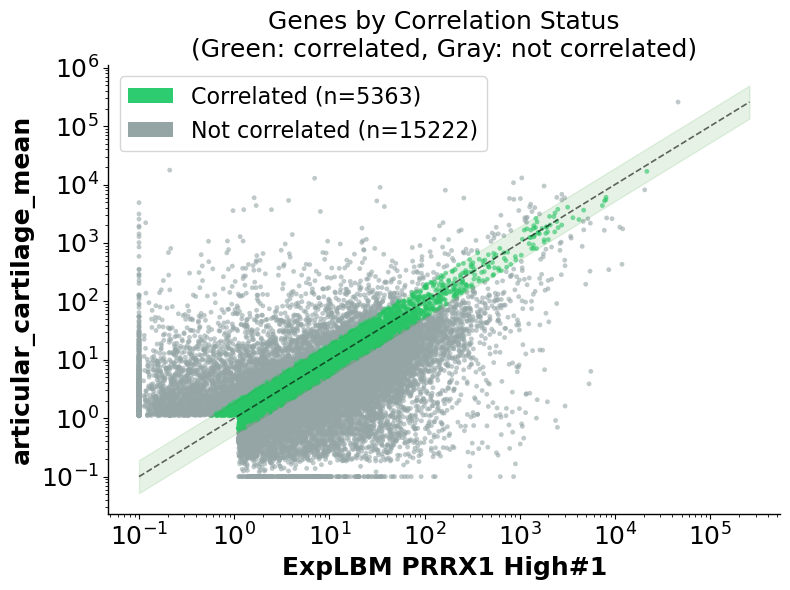


Distance threshold explanation:
- 0.2 log units = ~1.6x fold difference
Saved 5,363 genes to: /home/labs/davidgo/Collaboration/humanMPRA/paper/raw_plots/Yamada_correlated_genes_list.tsv


In [16]:
# Filter genes by distance from diagonal
# Uses existing DISTANCE_THRESHOLD variable (currently 0.1)
DISTANCE_THRESHOLD = 0.2 # log units (0.5 log units = ~3.16x fold difference)
# Prepare data
plot_df = Yamada_TPM[[x_col, y_col, "Symbol"]].copy()
plot_df[x_col] = pd.to_numeric(plot_df[x_col], errors="coerce")
plot_df[y_col] = pd.to_numeric(plot_df[y_col], errors="coerce")
plot_df = plot_df.dropna()

# Remove genes with TPM < 1 in BOTH datasets
before_filter_n = len(plot_df)
low_in_both_mask = (plot_df[x_col] < 1) & (plot_df[y_col] < 1)
removed_low_low_n = int(low_in_both_mask.sum())
plot_df = plot_df.loc[~low_in_both_mask].copy()
after_filter_n = len(plot_df)

print(f"Removed {removed_low_low_n:,} genes with TPM < 1 in both {x_col} and {y_col}.")
print(f"Remaining genes after TPM filter: {after_filter_n:,} (from {before_filter_n:,})")

# Values for plotting / distance (with pseudocount only for log safety)
x = plot_df[x_col].values + 0.1
y = plot_df[y_col].values + 0.1

# Calculate distance from diagonal in log space
x_log = np.log10(x)
y_log = np.log10(y)
distance_from_diag = np.abs(y_log - x_log) / np.sqrt(2)

# Create list of correlated genes (after TPM filtering)
correlated_genes = plot_df.loc[distance_from_diag <= DISTANCE_THRESHOLD, "Symbol"].tolist()
print(f"\nNumber of genes within {DISTANCE_THRESHOLD} log units from diagonal: {len(correlated_genes)}")
print(f"Example genes: {correlated_genes[:10]}")

# Create scatter plot colored by correlation status
fig, ax = plt.subplots(figsize=(8, 6))

correlated_set = set(correlated_genes)
colors = np.array(
    ["#2ecc71" if gene in correlated_set else "#95a5a6" for gene in plot_df["Symbol"].values]
)

ax.scatter(x, y, alpha=0.6, s=12, c=colors, edgecolors="none")

# Add diagonal line
min_val = min(x.min(), y.min())
max_val = max(x.max(), y.max())
ax.plot([min_val, max_val], [min_val, max_val], "k--", linewidth=1.2, alpha=0.6)

# Add distance band around diagonal
diag_x = np.array([min_val, max_val])
diag_y_upper = diag_x * (10 ** (DISTANCE_THRESHOLD * np.sqrt(2)))
diag_y_lower = diag_x / (10 ** (DISTANCE_THRESHOLD * np.sqrt(2)))
ax.fill_between(
    diag_x, diag_y_lower, diag_y_upper,
    alpha=0.1, color="green", label=f"±{DISTANCE_THRESHOLD} log units"
)

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel(x_col, fontsize=FONT_SIZE_small)
ax.set_ylabel(y_col, fontsize=FONT_SIZE_small)
ax.set_title(
    "Genes by Correlation Status\n(Green: correlated, Gray: not correlated)",
    fontsize=FONT_SIZE_small
)

# Custom legend
legend_elements = [
    Patch(facecolor="#2ecc71", label=f"Correlated (n={len(correlated_genes)})"),
    Patch(facecolor="#95a5a6", label=f"Not correlated (n={len(plot_df)-len(correlated_genes)})"),
]
ax.legend(handles=legend_elements, loc="upper left", fontsize=FONT_SIZE_small - 2)

plt.tight_layout()
plt.savefig(output_path + "Yamada_correlated_genes_annotation.png", bbox_inches="tight", dpi=300)
plt.show()

print("\nDistance threshold explanation:")
print(f"- {DISTANCE_THRESHOLD} log units = ~{10**(DISTANCE_THRESHOLD):.1f}x fold difference")

# Save correlated gene list (after TPM filtering)
correlated_genes_tsv = pd.DataFrame({"Symbol": correlated_genes})
correlated_genes_tsv.to_csv(
    output_path + "Yamada_correlated_genes_list.tsv",
    sep="\t",
    index=False
)

print(f"Saved {len(correlated_genes_tsv):,} genes to: {output_path}Yamada_correlated_genes_list.tsv")


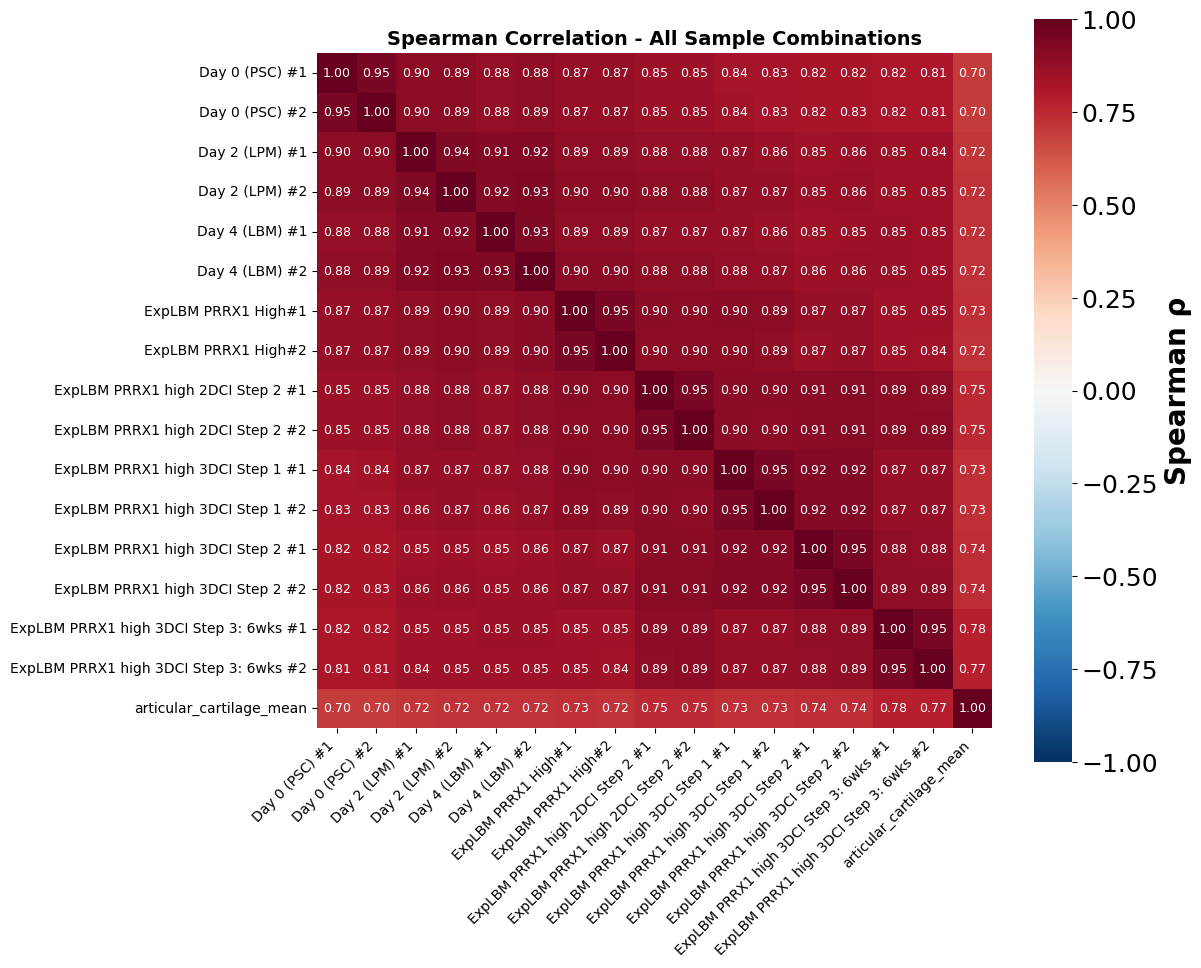

Spearman Correlation Matrix:
                                        Day 0 (PSC) #1  Day 0 (PSC) #2  \
Day 0 (PSC) #1                                1.000000        0.948450   
Day 0 (PSC) #2                                0.948450        1.000000   
Day 2 (LPM) #1                                0.895295        0.895729   
Day 2 (LPM) #2                                0.891608        0.892790   
Day 4 (LBM) #1                                0.877403        0.878113   
Day 4 (LBM) #2                                0.884702        0.885741   
ExpLBM PRRX1 High#1                           0.869056        0.869775   
ExpLBM PRRX1 High#2                           0.869886        0.871404   
ExpLBM PRRX1 high 2DCI Step 2 #1              0.851577        0.853008   
ExpLBM PRRX1 high 2DCI Step 2 #2              0.851844        0.853370   
ExpLBM PRRX1 high 3DCI Step 1 #1              0.835112        0.836025   
ExpLBM PRRX1 high 3DCI Step 1 #2              0.830266        0.830073   
ExpLBM PR

In [98]:
# Create Spearman correlation grid plot (log-transformed data)
import seaborn as sns
from scipy.stats import pearsonr, spearmanr

# Prepare data - exclude 'Symbol' column and drop NAs
cols_for_corr = Yamada_TPM.columns[1:]  # Exclude 'Symbol'
corr_data = Yamada_TPM[cols_for_corr].apply(pd.to_numeric, errors='coerce').dropna()

# Log-transform the data (add pseudocount to avoid log(0))
corr_data_log = np.log10(corr_data + 0.1)

# Calculate Spearman correlation matrix on log-transformed data
spearman_corr_matrix = corr_data_log.corr(method='spearman')

# Plot Spearman correlation
fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(spearman_corr_matrix, 
            annot=True, 
            fmt='.2f', 
            cmap='RdBu_r', 
            center=0, 
            vmin=-1, 
            vmax=1,
            cbar_kws={'label': 'Spearman ρ'},
            ax=ax,
            square=True,
            annot_kws={'fontsize': 9})
ax.set_title('Spearman Correlation - All Sample Combinations', fontsize=14, fontweight='bold')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=10)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=10)

plt.tight_layout()
plt.savefig(output_path + "Yamada_correlation_grid_spearman.png", bbox_inches='tight', dpi=300)
plt.show()

print("Spearman Correlation Matrix:")
print(spearman_corr_matrix)

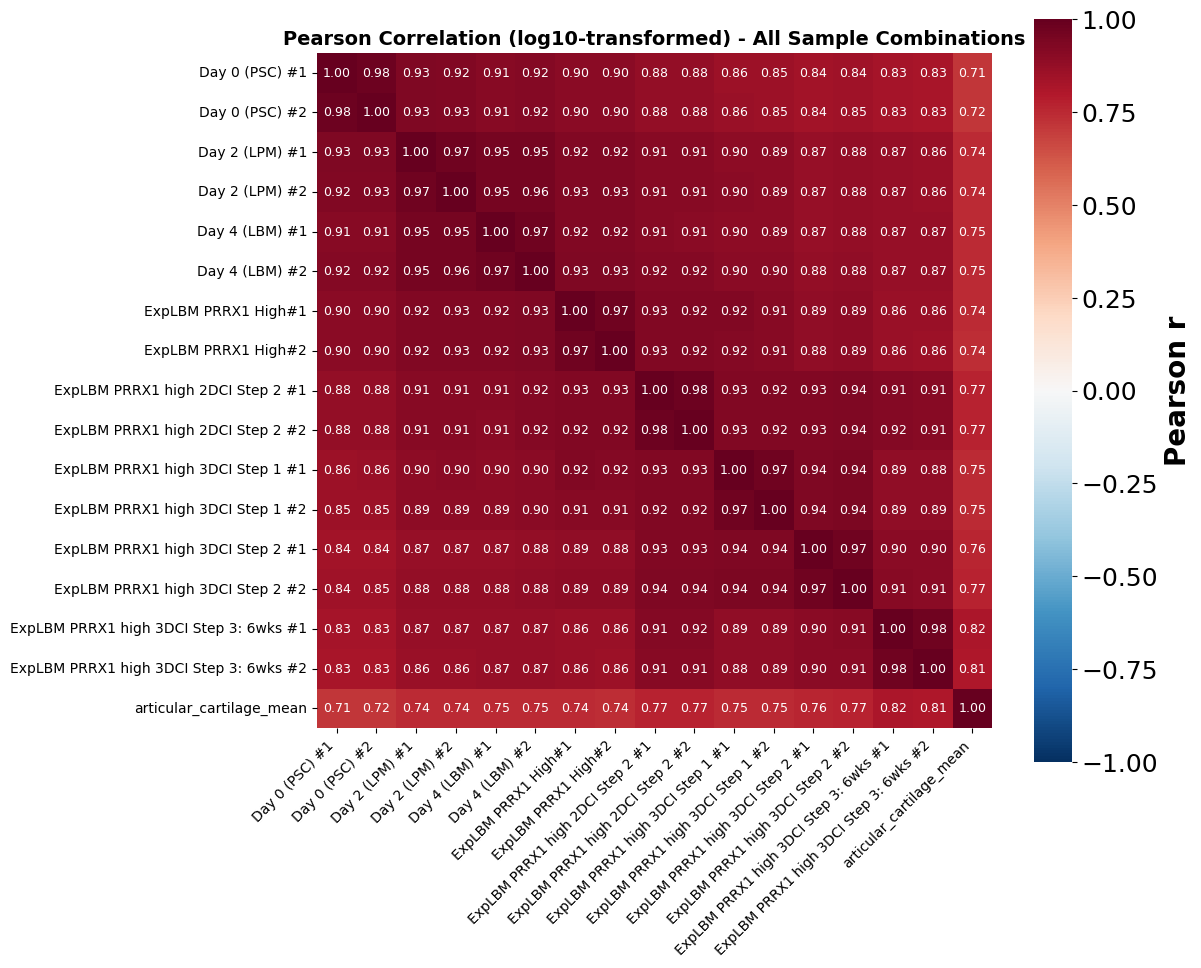

Pearson Correlation Matrix:
                                        Day 0 (PSC) #1  Day 0 (PSC) #2  \
Day 0 (PSC) #1                                1.000000        0.977977   
Day 0 (PSC) #2                                0.977977        1.000000   
Day 2 (LPM) #1                                0.931024        0.932040   
Day 2 (LPM) #2                                0.923827        0.925377   
Day 4 (LBM) #1                                0.912581        0.913796   
Day 4 (LBM) #2                                0.917689        0.918920   
ExpLBM PRRX1 High#1                           0.900740        0.901388   
ExpLBM PRRX1 High#2                           0.902788        0.904006   
ExpLBM PRRX1 high 2DCI Step 2 #1              0.879344        0.880832   
ExpLBM PRRX1 high 2DCI Step 2 #2              0.878914        0.880301   
ExpLBM PRRX1 high 3DCI Step 1 #1              0.858181        0.859488   
ExpLBM PRRX1 high 3DCI Step 1 #2              0.852538        0.852831   
ExpLBM PRR

In [99]:
# Create Pearson correlation grid plot (log-transformed data)
# Calculate Pearson correlation matrix on log-transformed data
pearson_corr_matrix = corr_data_log.corr(method='pearson')

# Plot Pearson correlation
fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(pearson_corr_matrix, 
            annot=True, 
            fmt='.2f', 
            cmap='RdBu_r', 
            center=0, 
            vmin=-1, 
            vmax=1,
            cbar_kws={'label': 'Pearson r'},
            ax=ax,
            square=True,
            annot_kws={'fontsize': 9})
ax.set_title('Pearson Correlation (log10-transformed) - All Sample Combinations', fontsize=14, fontweight='bold')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=10)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=10)

plt.tight_layout()
plt.savefig(output_path + "Yamada_correlation_grid_pearson_log.png", bbox_inches='tight', dpi=300)
plt.show()

print("Pearson Correlation Matrix:")
print(pearson_corr_matrix)

# Comparing the trans environemnt of chimp and human using the parental CNCCs

i want you to read the excel file that is located in /home/labs/davidgo/Collaboration/USEFUL_DATASETS/Expression/Hybrids/human_chimp/iPSCs_and_CNCCs/iPSCs_CNCCs_ASE.xlsx. Specifically, read the sheet called SUMMARY and skip the first three rows. Finally, save it into a df called CNCC_parental which will contain only the following cols: "FPKM - ((reads/libSize)/CDS)*10^6 - CNCC - Parental human" "FPKM - ((reads/libSize)/CDS)*10^6 - CNCC - Parental chimp" and "gene"

In [28]:
cncc_path = "/home/labs/davidgo/Collaboration/USEFUL_DATASETS/Expression/Hybrids/human_chimp/iPSCs_and_CNCCs/iPSCs_CNCCs_ASE.xlsx"

cncc_cols = [
    "FPKM - ((reads/libSize)/CDS)*10^6 - CNCC - Parental human",
    "FPKM - ((reads/libSize)/CDS)*10^6 - CNCC - Parental chimp",
    "gene",
]

CNCC_parental = pd.read_excel(
    cncc_path,
    sheet_name="SUMMARY",
    skiprows=3,
    usecols=cncc_cols
)

CNCC_parental.rename(columns={
    "FPKM - ((reads/libSize)/CDS)*10^6 - CNCC - Parental human": "Parental_Human_FPKM",
    "FPKM - ((reads/libSize)/CDS)*10^6 - CNCC - Parental chimp": "Parental_Chimp_FPKM",
    "gene": "Gene"
}, inplace=True)




Exception ignored in: <bound method IPythonKernel._clean_thread_parent_frames of <ipykernel.ipkernel.IPythonKernel object at 0x14a793d79760>>
Traceback (most recent call last):
  File "/home/labs/davidgo/nadavmi/.conda/envs/Nadav_python/lib/python3.12/site-packages/ipykernel/ipkernel.py", line 775, in _clean_thread_parent_frames
    def _clean_thread_parent_frames(

KeyboardInterrupt: 


### Filter for TFs that are in the JASPAR database

In [3]:
JASPAR_dataset = pd.read_csv(f'/home/labs/davidgo/Collaboration/USEFUL_DATASETS/Sequence/Motifs_and_TFBS/JASPAR2024/JASPAR2024_CORE_vertebrates_non-redundant_meta.tsv', 
                     sep = '\t',
                       #usecols=range(0, 34), 
                     header=0)
JASPAR_TFs = (
  JASPAR_dataset["TF"]
  .dropna()
  .astype(str)
  .str.upper()
  .str.split(r"::|-", regex=True)  # split on both "::" and "-"
  .explode()
  .str.strip()
  .replace("", np.nan)
  .dropna()
  .unique()
)

print(f"Number of CNCCs before TF filtering : {len(CNCC_parental)}")
CNCC_parental_TFs = CNCC_parental[CNCC_parental['Gene'].isin(JASPAR_TFs)].copy()
print(f"Number of TFs in CNCC parental dataset: {len(CNCC_parental_TFs)}")

NameError: name 'CNCC_parental' is not defined

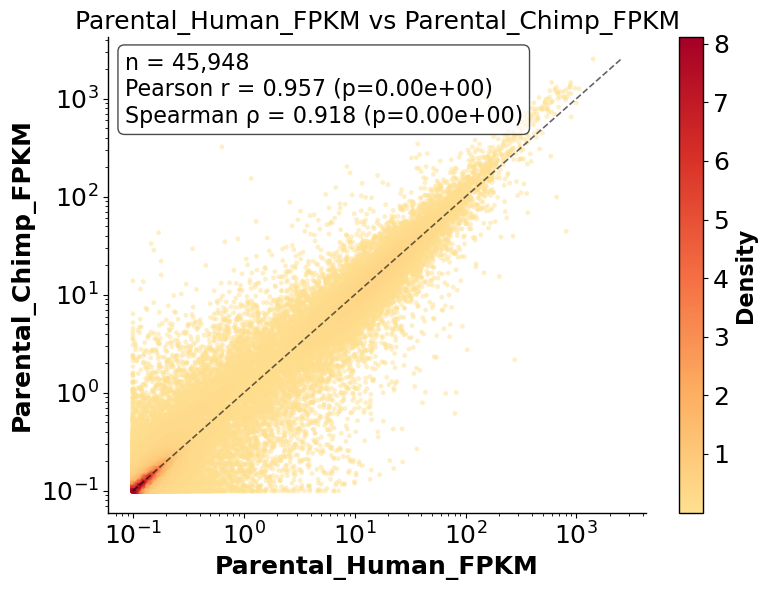

{'n': 45948, 'pearson_r': np.float64(0.9568897341991911), 'pearson_p': np.float64(0.0), 'spearman_r': np.float64(0.9180967961471974), 'spearman_p': np.float64(0.0)}


In [126]:
corr_stats = plot_scatter_correlation(
    CNCC_parental,
    x_col='Parental_Human_FPKM',
    y_col='Parental_Chimp_FPKM',
    #title="Correlation between ExpLBM PRRX1 High#1 and 3DCI Step 3: 6wks #1",
    save_path=output_path + "CNCC_Parental_Human_vs_Chimp_scatter.png",
)

print(corr_stats)


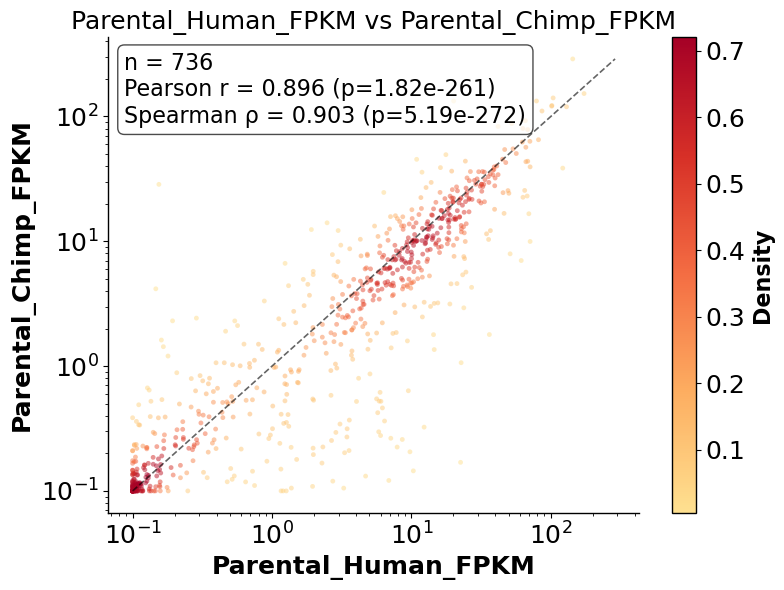

{'n': 736, 'pearson_r': np.float64(0.8963261965025622), 'pearson_p': np.float64(1.823710080024349e-261), 'spearman_r': np.float64(0.9033183946695961), 'spearman_p': np.float64(5.18638305686761e-272)}


In [129]:
corr_stats = plot_scatter_correlation(
    CNCC_parental_TFs,
    x_col='Parental_Human_FPKM',
    y_col='Parental_Chimp_FPKM',
    #title="Correlation between ExpLBM PRRX1 High#1 and 3DCI Step 3: 6wks #1",
    save_path=output_path + "CNCC_Parental_Human_vs_Chimp_scatter.png",
)

print(corr_stats)



## Comparing human and Chimp trans environment using (Housman et al paper)
https://journals.plos.org/plosgenetics/article?id=10.1371/journal.pgen.1010073#sec025

In [19]:
bone_excel_path = "/home/labs/davidgo/Collaboration/USEFUL_DATASETS/Expression/Bone/Human/RNA-seq/In_vitro_osteogenic_cells_DE_housman.xlsx"
bone_df = pd.read_excel(bone_excel_path)

print(f"Before filtering : {len(bone_df)}")
bone_df = bone_df[bone_df['cell.subset']=='Osteogenic.c1']
print(f"After filtering : {len(bone_df)}")

Before filtering : 13760
After filtering : 1177


In [20]:
tf_bone_df = bone_df[bone_df['Gene'].isin(JASPAR_TFs)].copy()

In [21]:
Housman_diff_active_tfs = (
    tf_bone_df["Gene"]
    .dropna()
    .astype(str)
    .str.upper()
    .unique()
)

print(f"Number of unique TF genes: {len(Housman_diff_active_tfs)}")
print(Housman_diff_active_tfs)

Number of unique TF genes: 14
['YY2' 'ZNF93' 'STAT1' 'E2F4' 'MSANTD3' 'PBX2' 'PBX3' 'RFX2' 'ZNF784'
 'BCL11A' 'HSF4' 'ZNF701' 'NFKB1' 'PRRX2']


### Load TF data

In [23]:
TF_data_path = "/home/labs/davidgo/Collaboration/humanMPRA/TF_analysis/final/results/hMPRA_PBM_oligo_TF_merged.tsv"

PBM_data = pd.read_csv(TF_data_path, sep='\t')

In [27]:
PBM_data['motif_id_clean'] = PBM_data['motif_id_clean'].str.upper()

In [29]:
bone_PBM_TF_data = PBM_data[PBM_data['motif_id_clean'].isin(Housman_diff_active_tfs)].copy()

In [33]:
len(bone_PBM_TF_data['seq_id'].unique())

32281

In [34]:
bone_PBM_TF_data

,seq_id,chr,number_of_variants,diff_binding_score,diff_binding_zscore,diff_binding_pval,diff_binding_fdr,motif_association_method,cell_type_used_for_motif_filtering,Mus_musculus,motif_id_clean
41,seq_100003_chr8:34830463-34830732_SCREEN_a3_L1,chr8,2,1.097424,0.205415,0.418624,0.500000,PBM,chondrocytes,True,E2F4
96,seq_100010_chr2:21686032-21686301_SCREEN_a3_L1,chr2,2,1.819052,0.899931,0.184079,0.326393,PBM,chondrocytes,False,RFX2
139,seq_100014_chr1:11012843-11013112_SCREEN_a3_L1,chr1,1,1.357101,1.136098,0.127958,0.261153,PBM,chondrocytes,False,RFX2
425,seq_100036_chr13:66980610-66980879_SCREEN_a3_L1,chr13,1,0.904023,0.000000,0.500000,0.500000,PBM,chondrocytes,False,RFX2
479,seq_100044_chr12:124101641-124101910_SCREEN_a3_L1,chr12,2,1.733703,3.518522,0.000217,0.002339,PBM,chondrocytes,False,RFX2
...,...,...,...,...,...,...,...,...,...,...,...
4193199,seq_99943_chr20:36672460-36672729_SCREEN_a3_L1,chr20,3,0.637939,-0.993202,0.160306,0.300250,PBM,chondrocytes,True,E2F4
4193521,seq_99964_chr2:230275713-230275982_SCREEN_a3_L1,chr2,1,1.343588,2.403156,0.008127,0.036263,PBM,chondrocytes,False,RFX2
4193628,seq_99975_chr1:119875388-119875657_SCREEN_a3_L1,chr1,1,1.149614,1.333313,0.091215,0.210236,PBM,chondrocytes,False,RFX2
4193646,seq_99977_chr10:123690022-123690291_SCREEN_a3_L1,chr10,2,1.782693,4.428632,0.000005,0.000464,PBM,chondrocytes,False,RFX2
